# Train models

Run the setup once, then execute each experiment cell independently. Each experiment cell shows its overrides and
launches training so configuration and execution stay together.


In [1]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package to ensure using the local code.
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [2]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from config import build_config_from_dict
from training import Trainer

RUNS_ROOT = Path("training_runs")
RUNS_ROOT.mkdir(exist_ok=True)

SESSION_TAG = f"resampled_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
print(f"Session prefix: {SESSION_TAG}")

Session prefix: resampled_20251207-123736


In [3]:
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

PLOTS_DIR = None  # set per run below

def set_plot_dir(path: Path):
    global PLOTS_DIR
    PLOTS_DIR = path
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    return PLOTS_DIR

def save_fig(fig, name: str, prefix: str = "train"):
    assert PLOTS_DIR is not None, "PLOTS_DIR not set; call set_plot_dir(...) first."
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches="tight", format="pdf")
    print(f"Saved figure to {path}")
    return path

## Base config for all experiments

In [ ]:
BASE_OVERRIDES = {
    "data_root": str(Path("data_resampled")),
    "epochs": 50,
    "batch_size": 64,
    "optimizer": "adamw",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "wandb_mode": "disabled",
    "tensorboard": False,
    "progress_bar": True,
    "amp": True,
    "early_stopping": 12,
    "grad_clip_norm": 1.0,
    "label_smoothing": 0.05,
    "balance_strategy": "weighted_sampler",
    "image_size": 256,
    "apply_temperature": False,
    "data_integrity_check": True,
}

pd.DataFrame([BASE_OVERRIDES]).T.rename(columns={0: "value"})

,value
data_root,data_resampled
epochs,50
batch_size,64
optimizer,adamw
lr,0.0003
weight_decay,0.0001
wandb_mode,disabled
tensorboard,False
progress_bar,True
amp,True


## Experiment Helpers


In [5]:
import matplotlib.cm as cm

def plot_training_curves(train_summary: dict, cfg):
    history_df = pd.DataFrame(train_summary.get("history", []))
    if history_df.empty:
        print("No history logged; nothing to plot.")
        return

    model_name = getattr(cfg, "model_name", "model")
    best_epoch = train_summary.get("best_epoch")
    if best_epoch is not None and best_epoch < 0:
        best_epoch = None

    # Losses
    fig, ax = plt.subplots(figsize=(8, 4.5))
    history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", linewidth=1.6, ax=ax)
    if best_epoch is not None:
        ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.1, label="best_epoch")
    ax.set_ylabel("Loss")
    ax.set_xlabel("Epoch")
    ax.set_title(f"{model_name} | Loss curves")
    ax.grid(alpha=0.25)
    ax.legend()
    save_fig(fig, "loss_curves")
    plt.show()

    # Metrics stacked plots
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    top_metrics = {
        "val/accuracy": "Accuracy",
        "val/macro_precision": "Macro Precision",
        "val/macro_recall": "Macro Recall",
        "val/macro_f1": "Macro F1",
    }
    bottom_metrics = {
        "val/brier": "Brier",
        "val/ece": "ECE",
    }

    colors = cm.get_cmap("tab10")

    for idx, (col, label) in enumerate(top_metrics.items()):
        if col in history_df.columns:
            axes[0].plot(history_df["epoch"], history_df[col], marker="o", linewidth=1.6, label=label, color=colors(idx))
    if best_epoch is not None:
        axes[0].axvline(best_epoch, color="gray", linestyle="--", linewidth=1.0, label="best_epoch")
    axes[0].set_ylabel("Metric")
    axes[0].set_title(f"{model_name} | Accuracy/Precision/Recall/F1")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    for idx, (col, label) in enumerate(bottom_metrics.items()):
        if col in history_df.columns:
            axes[1].plot(history_df["epoch"], history_df[col], marker="o", linewidth=1.6, label=label, color=colors(idx+4))
    if best_epoch is not None:
        axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1.0, label="best_epoch")
    axes[1].set_ylabel("Metric")
    axes[1].set_xlabel("Epoch")
    axes[1].set_title(f"{model_name} | Calibration metrics (Brier/ECE)")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.tight_layout()
    save_fig(fig, "metrics")
    plt.show()

def run_experiment(name: str, cfg_dict: dict, skip_if_exists: bool = True):
    cfg = build_config_from_dict(cfg_dict)

    run_dir = RUNS_ROOT / f"{SESSION_TAG}_{name}"
    plots_dir = run_dir / "plots"
    artifacts_dir = run_dir / "artifacts"
    checkpoints_dir = artifacts_dir / "checkpoints"
    tensorboard_dir = artifacts_dir / "tensorboard"
    for d in (plots_dir, checkpoints_dir, tensorboard_dir):
        d.mkdir(parents=True, exist_ok=True)

    cfg.checkpoints_dir = str(checkpoints_dir)
    cfg.tensorboard_dir = str(tensorboard_dir)

    (run_dir / "config.json").write_text(json.dumps(cfg.to_dict(), indent=2))

    train_summary_path = run_dir / "train_summary.json"
    if skip_if_exists and train_summary_path.exists():
        print(f"Found existing training summary in {run_dir}, loading from disk (skip training).")
        train_summary = json.loads(train_summary_path.read_text())
        set_plot_dir(plots_dir)
        plot_training_curves(train_summary, cfg)
        return {
            "name": name,
            "cfg": cfg,
            "run_dir": run_dir,
            "train_summary": train_summary,
        }

    set_plot_dir(plots_dir)

    trainer = Trainer(cfg)
    train_summary = trainer.fit()

    train_summary_path.write_text(json.dumps(train_summary, indent=2))
    plot_training_curves(train_summary, cfg)

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Finished training {name} -> {run_dir}")
    print(f"Best validation {cfg.checkpoint_metric}: {train_summary.get('best_metric'):.4f}")
    return {
        "name": name,
        "cfg": cfg,
        "run_dir": run_dir,
        "train_summary": train_summary,
    }

Epoch 1/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-07 12:37:55,965 | INFO | Epoch 000 | train_loss=0.1926 | val_loss=0.2771 | val_f1=0.911


Epoch 2/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-07 12:38:17,753 | INFO | Epoch 001 | train_loss=0.1527 | val_loss=0.2580 | val_f1=0.911


Epoch 3/50:   0%|          | 0/296 [00:00<?, ?it/s]

...

Epoch 43/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-07 12:51:23,498 | INFO | Epoch 042 | train_loss=0.1175 | val_loss=0.1417 | val_f1=0.985


Epoch 44/50:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-07 12:51:44,329 | INFO | Epoch 043 | train_loss=0.1174 | val_loss=0.1418 | val_f1=0.987
2025-12-07 12:51:44,329 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_resnet18/plots/train_loss_curves.pdf


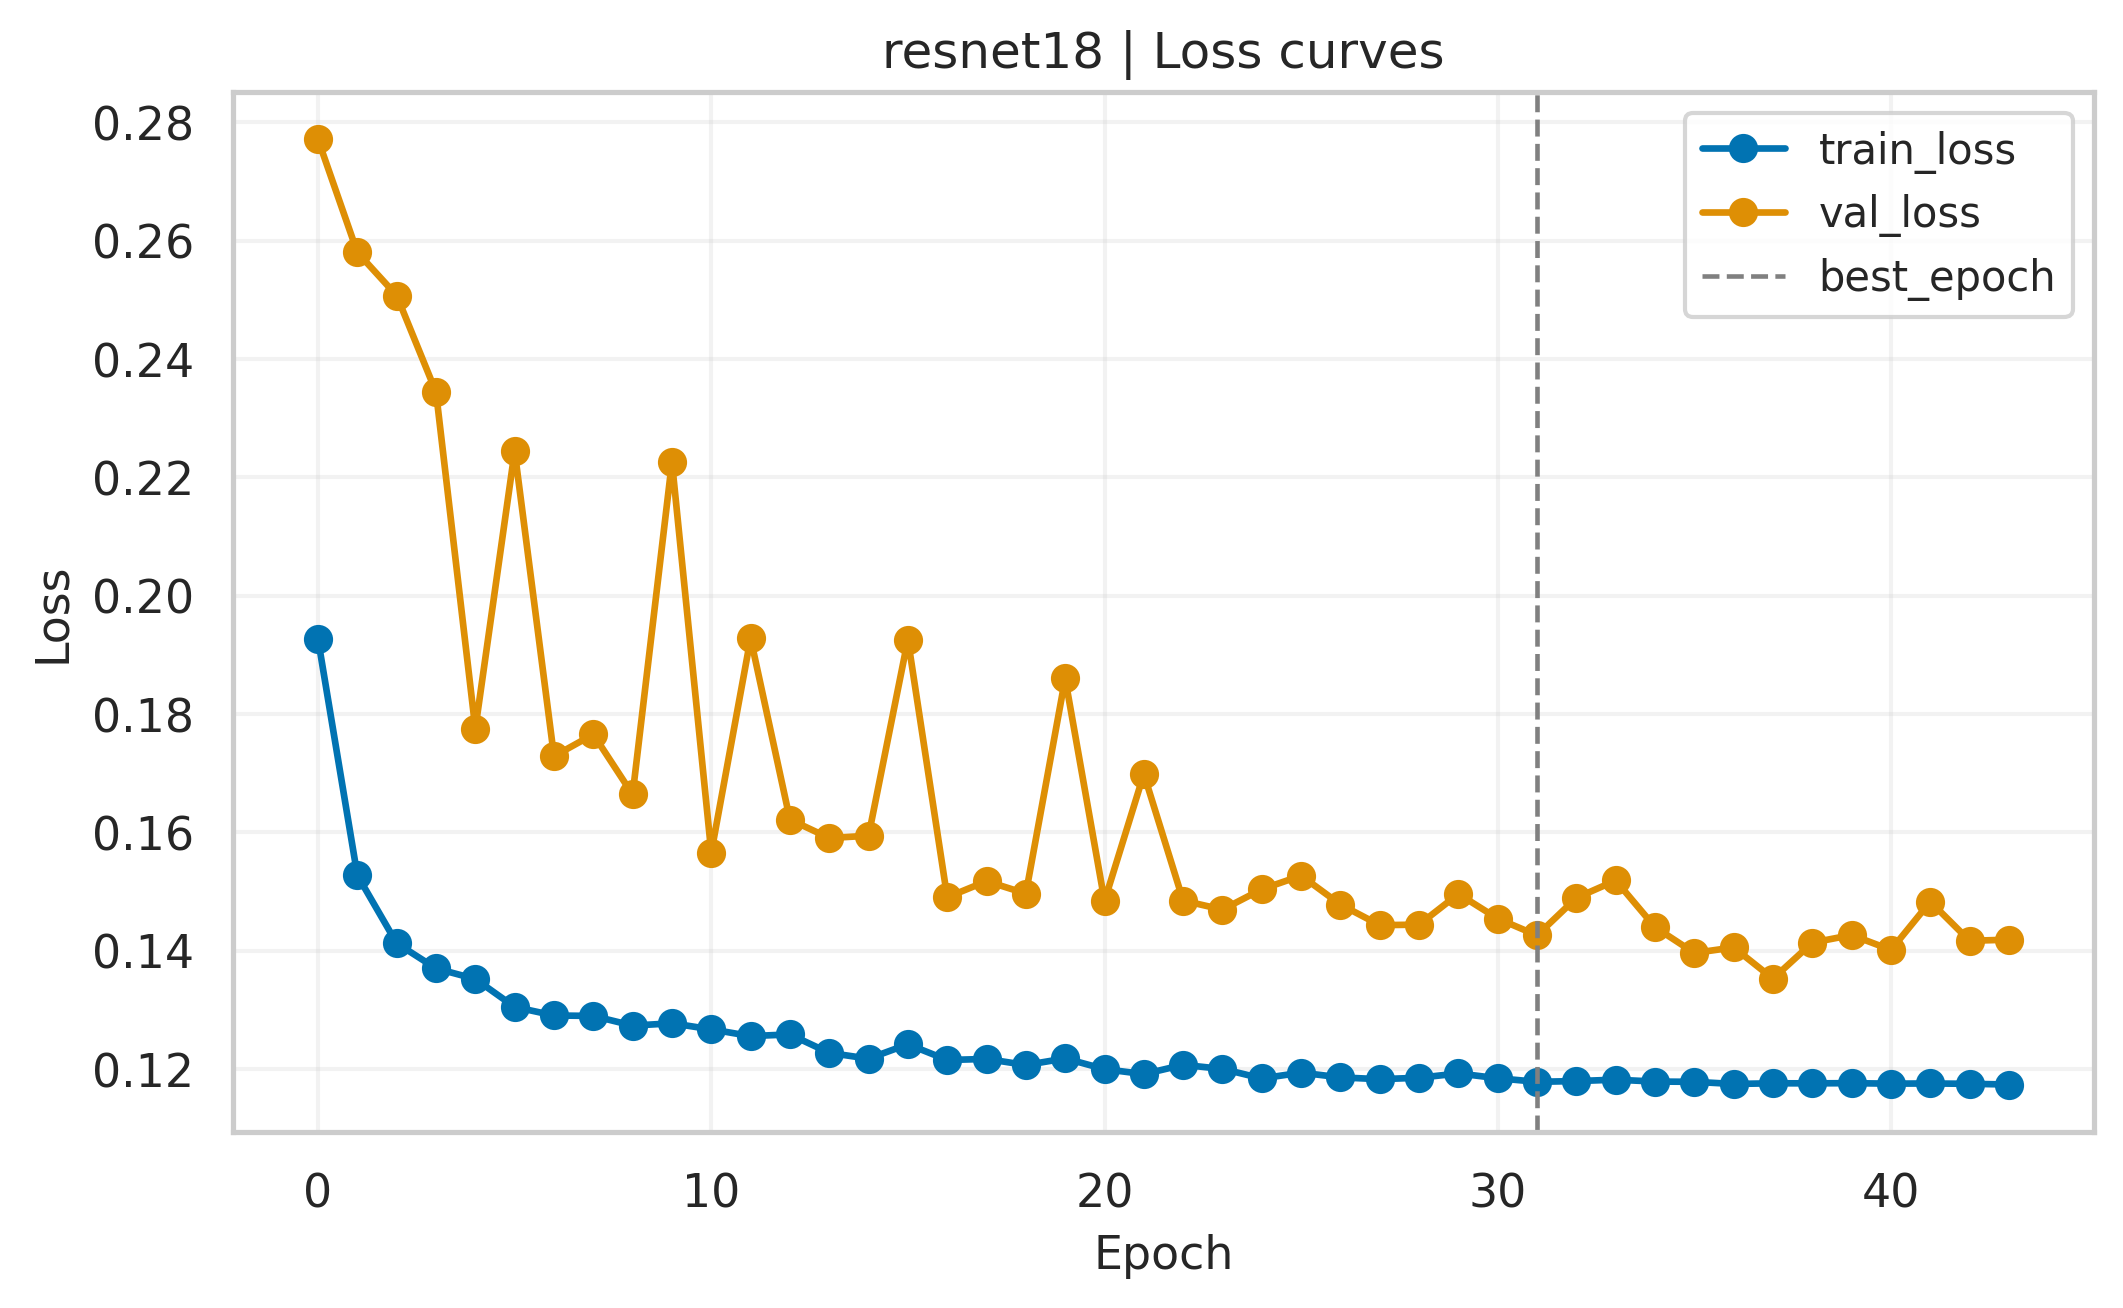

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_resnet18/plots/train_metrics.pdf


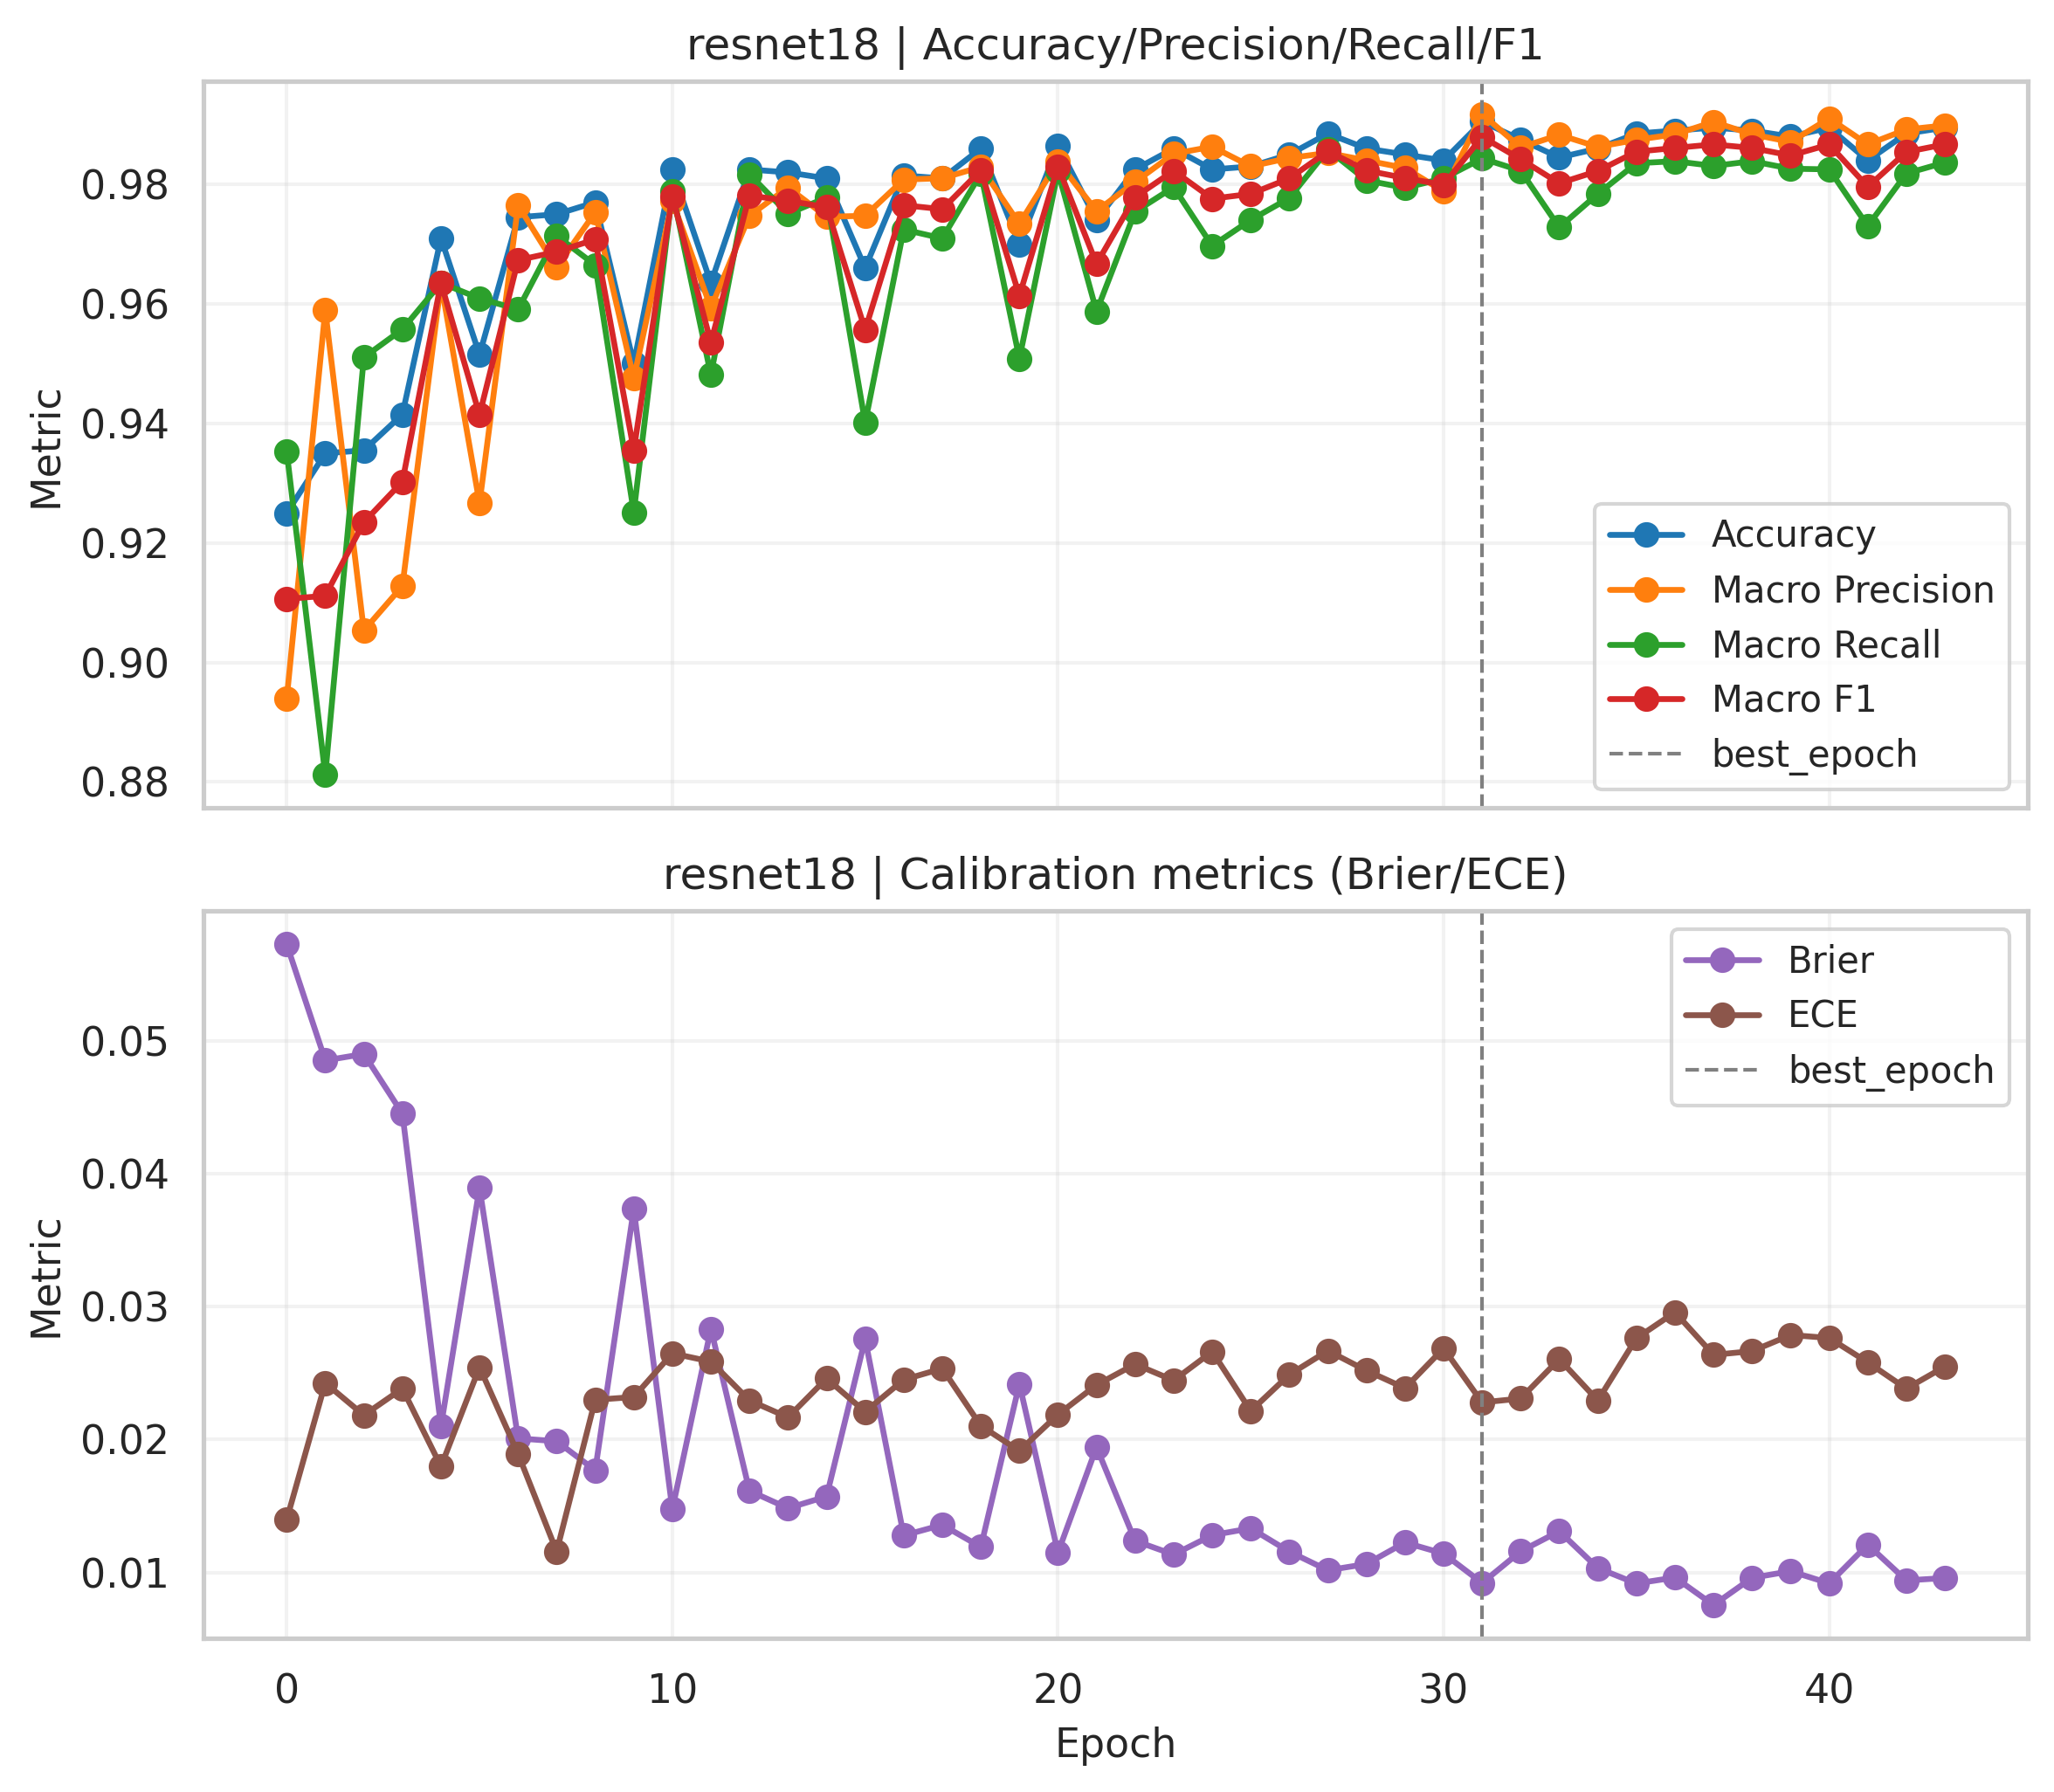

Finished training resnet18 -> training_runs/resampled_20251207-123736_resnet18
Best validation macro_f1: 0.9880


In [6]:
# resnet18 configuration + training
resnet18_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet18', 'batch_size': 64, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet18_run = run_experiment("resnet18", resnet18_overrides)

Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 12:52:04,122 | INFO | Epoch 000 | train_loss=0.2037 | val_loss=0.2041 | val_f1=0.941


Epoch 2/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 12:52:22,397 | INFO | Epoch 001 | train_loss=0.1590 | val_loss=0.1893 | val_f1=0.958


Epoch 3/50:   0%|          | 0/395 [00:00<?, ?it/s]

...

Epoch 28/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:00:36,433 | INFO | Epoch 027 | train_loss=0.1187 | val_loss=0.1489 | val_f1=0.982


Epoch 29/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:00:57,000 | INFO | Epoch 028 | train_loss=0.1199 | val_loss=0.1584 | val_f1=0.978
2025-12-07 13:00:57,001 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_resnet34/plots/train_loss_curves.pdf


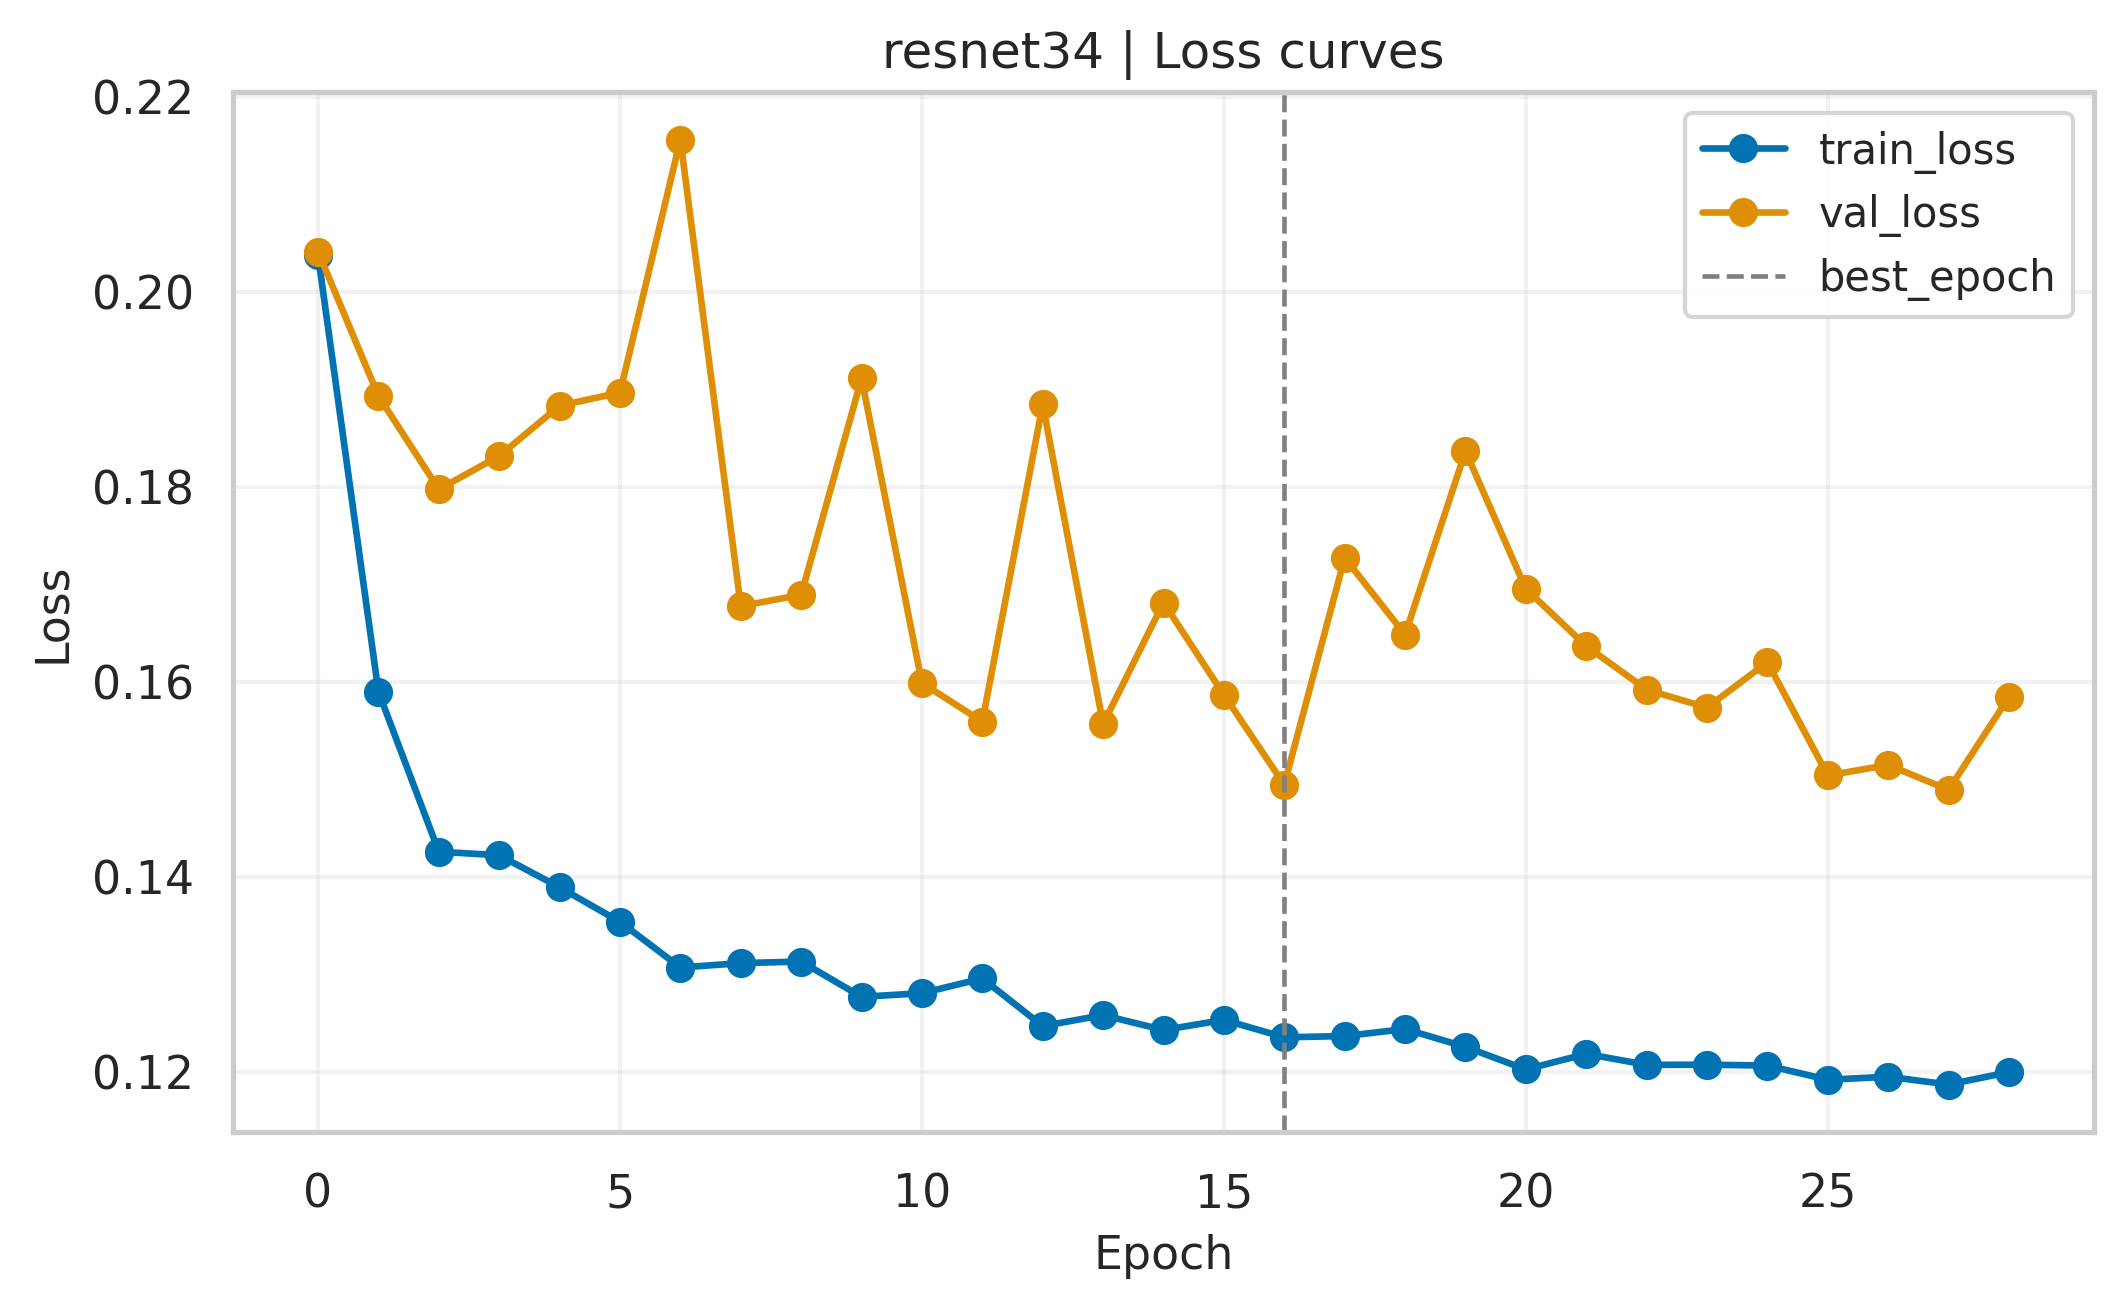

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_resnet34/plots/train_metrics.pdf


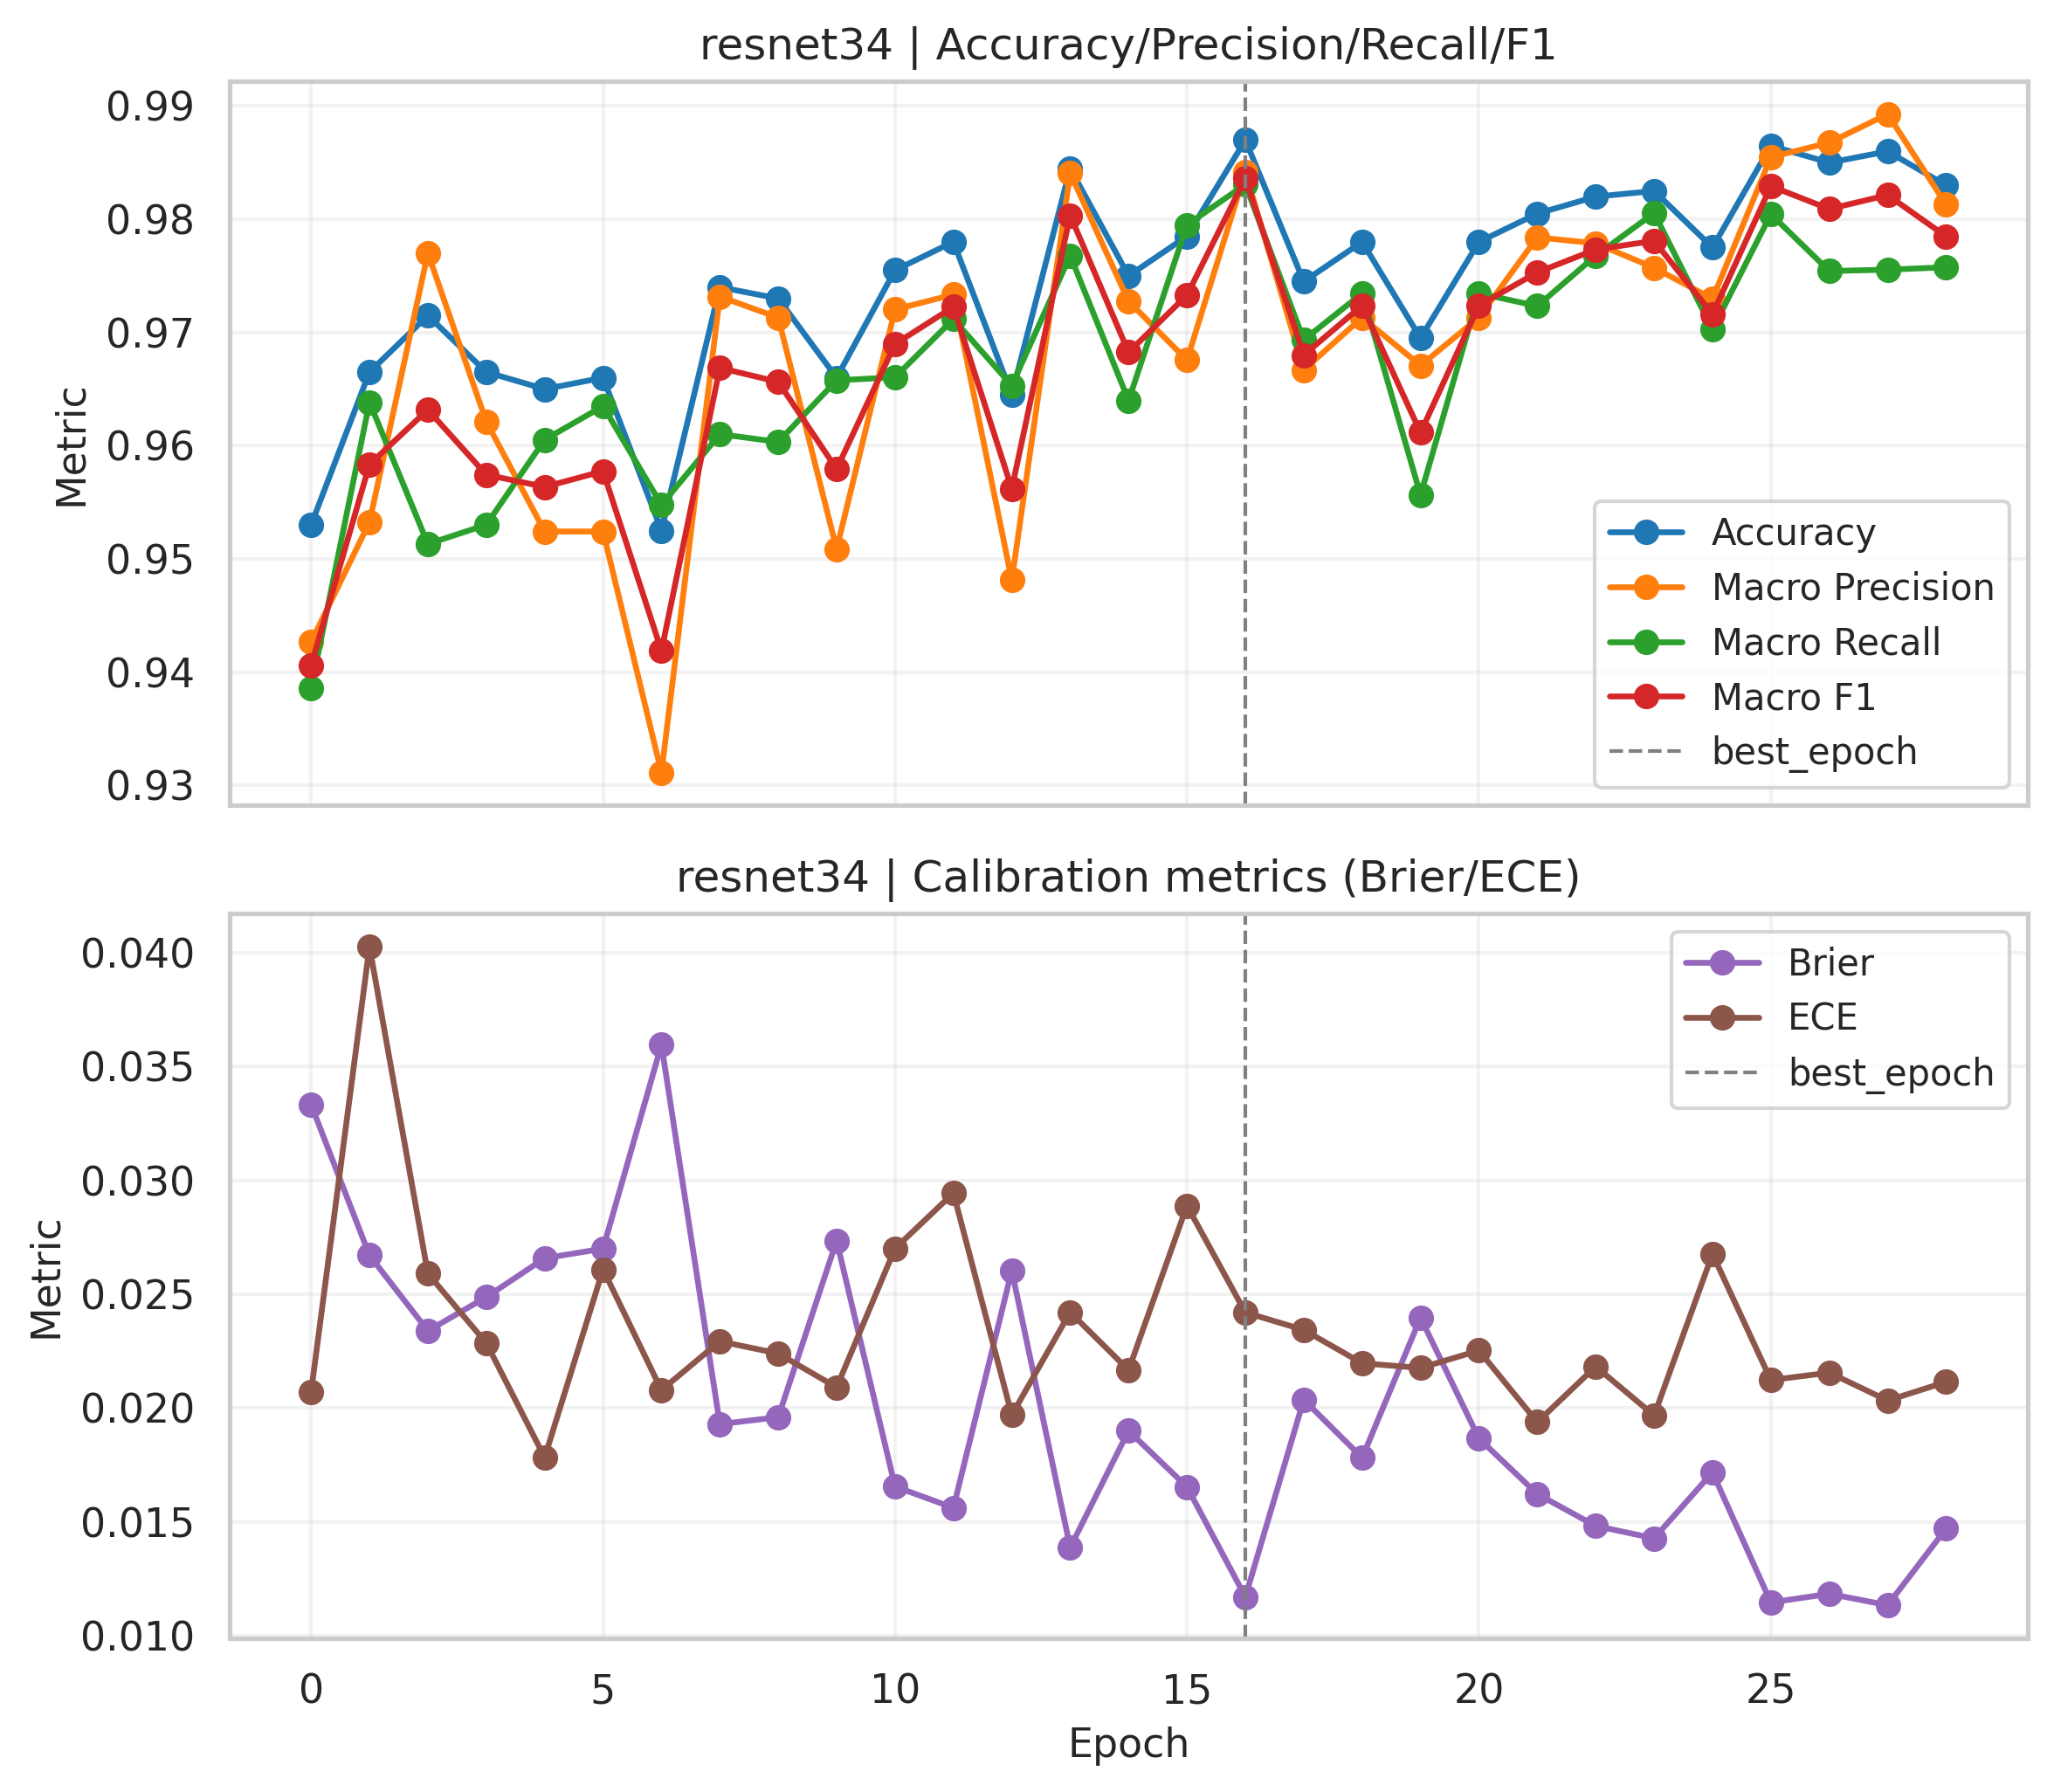

Finished training resnet34 -> training_runs/resampled_20251207-123736_resnet34
Best validation macro_f1: 0.9836


In [7]:
# resnet34 configuration + training
resnet34_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet34', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.2, 'image_size': 256}}
resnet34_run = run_experiment("resnet34", resnet34_overrides)

Epoch 1/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:01:21,361 | INFO | Epoch 000 | train_loss=0.1898 | val_loss=0.2122 | val_f1=0.941


Epoch 2/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:01:43,789 | INFO | Epoch 001 | train_loss=0.1479 | val_loss=0.2044 | val_f1=0.947


Epoch 3/50:   0%|          | 0/593 [00:00<?, ?it/s]

...

Epoch 49/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:19:49,133 | INFO | Epoch 048 | train_loss=0.1172 | val_loss=0.1399 | val_f1=0.987


Epoch 50/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:20:13,408 | INFO | Epoch 049 | train_loss=0.1172 | val_loss=0.1426 | val_f1=0.986


Saved figure to training_runs/resampled_20251207-123736_resnet50/plots/train_loss_curves.pdf


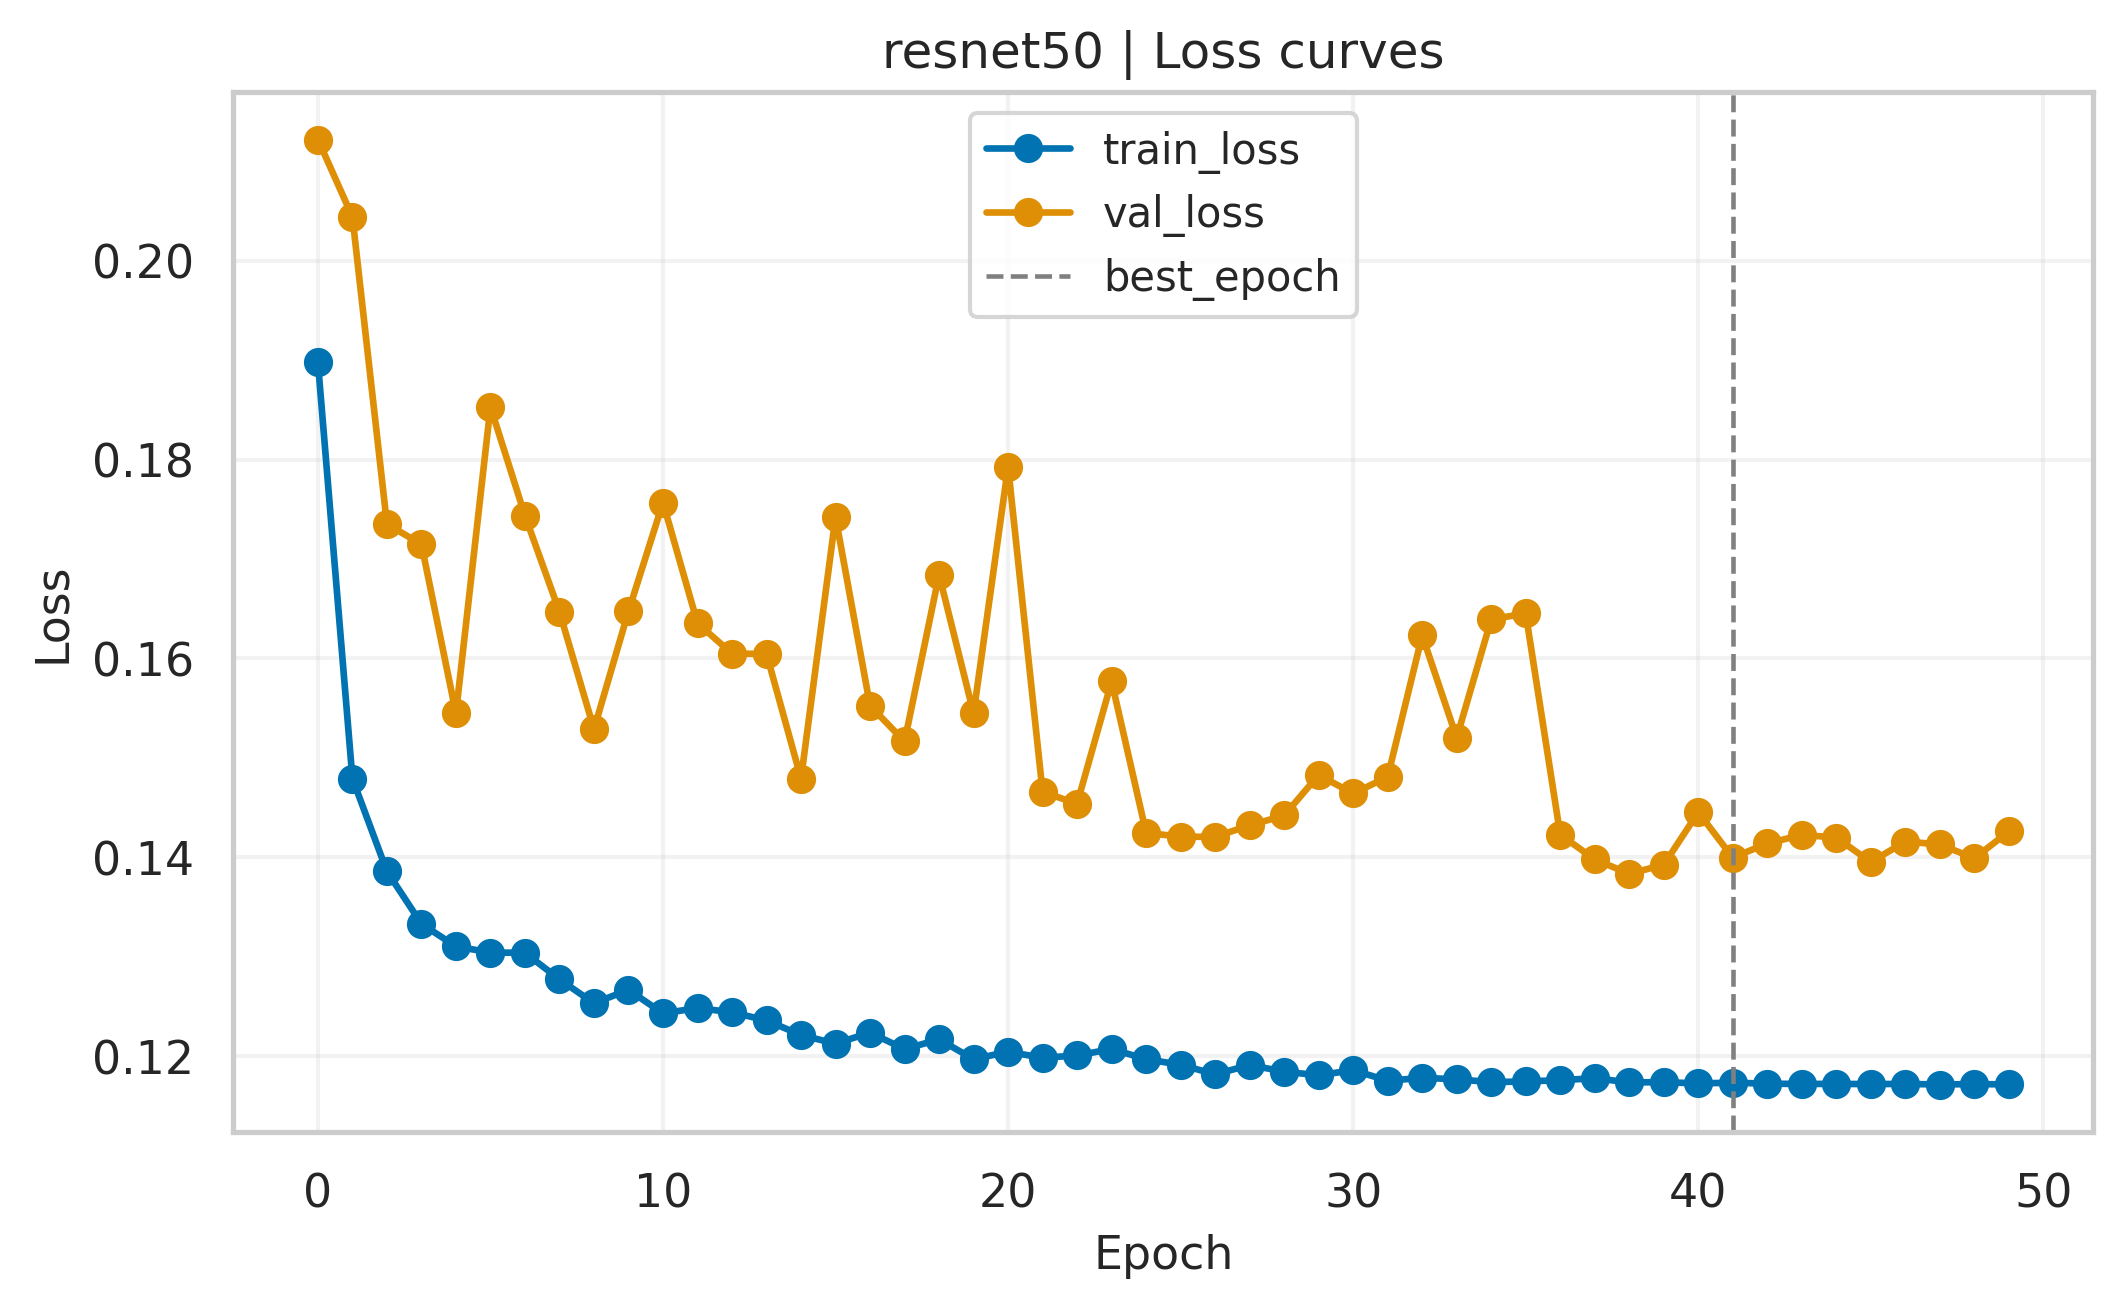

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_resnet50/plots/train_metrics.pdf


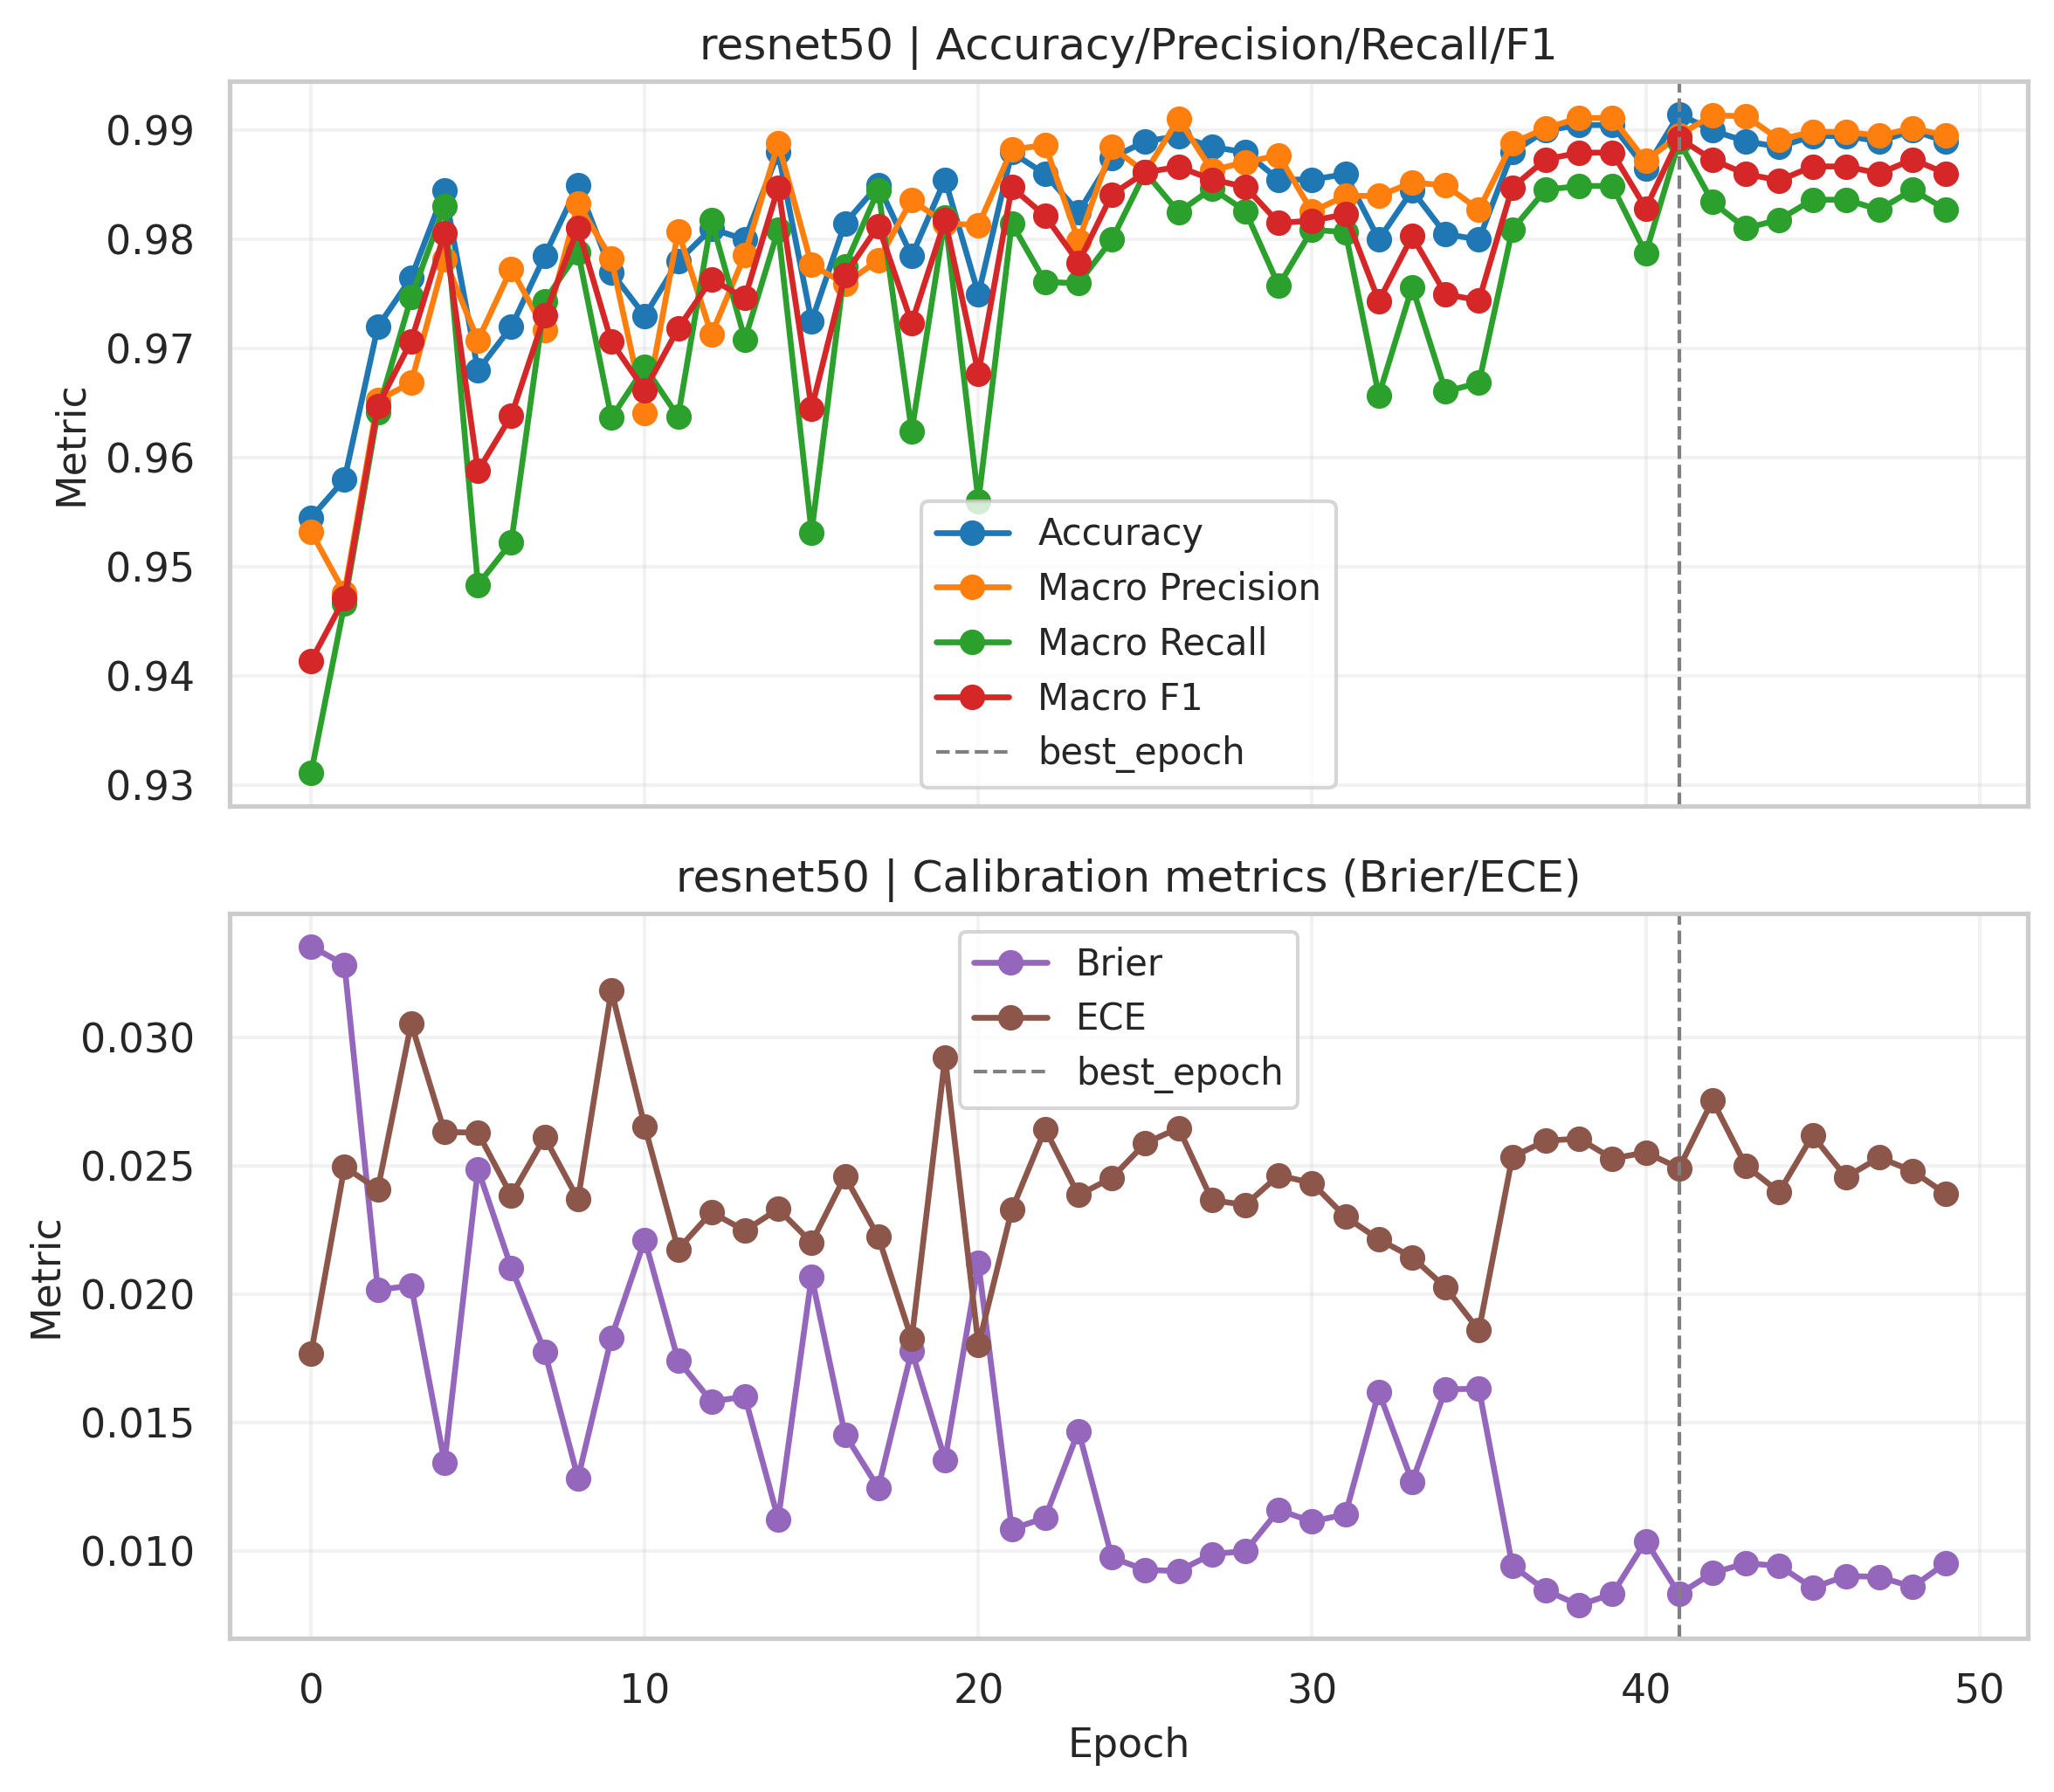

Finished training resnet50 -> training_runs/resampled_20251207-123736_resnet50
Best validation macro_f1: 0.9893


In [8]:
# resnet50 configuration + training
resnet50_overrides = {**BASE_OVERRIDES, **{'model_name': 'resnet50', 'batch_size': 32, 'lr': 0.00025, 'dropout': 0.25, 'image_size': 256}}
resnet50_run = run_experiment("resnet50", resnet50_overrides)

Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:20:42,551 | INFO | Epoch 000 | train_loss=0.1884 | val_loss=0.1964 | val_f1=0.953


Epoch 2/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:21:04,322 | INFO | Epoch 001 | train_loss=0.1412 | val_loss=0.1705 | val_f1=0.965


Epoch 3/50:   0%|          | 0/395 [00:00<?, ?it/s]

...

Epoch 24/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:28:48,645 | INFO | Epoch 023 | train_loss=0.1181 | val_loss=0.1438 | val_f1=0.986


Epoch 25/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:29:09,250 | INFO | Epoch 024 | train_loss=0.1175 | val_loss=0.1410 | val_f1=0.987
2025-12-07 13:29:09,251 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_efficientnet_b1/plots/train_loss_curves.pdf


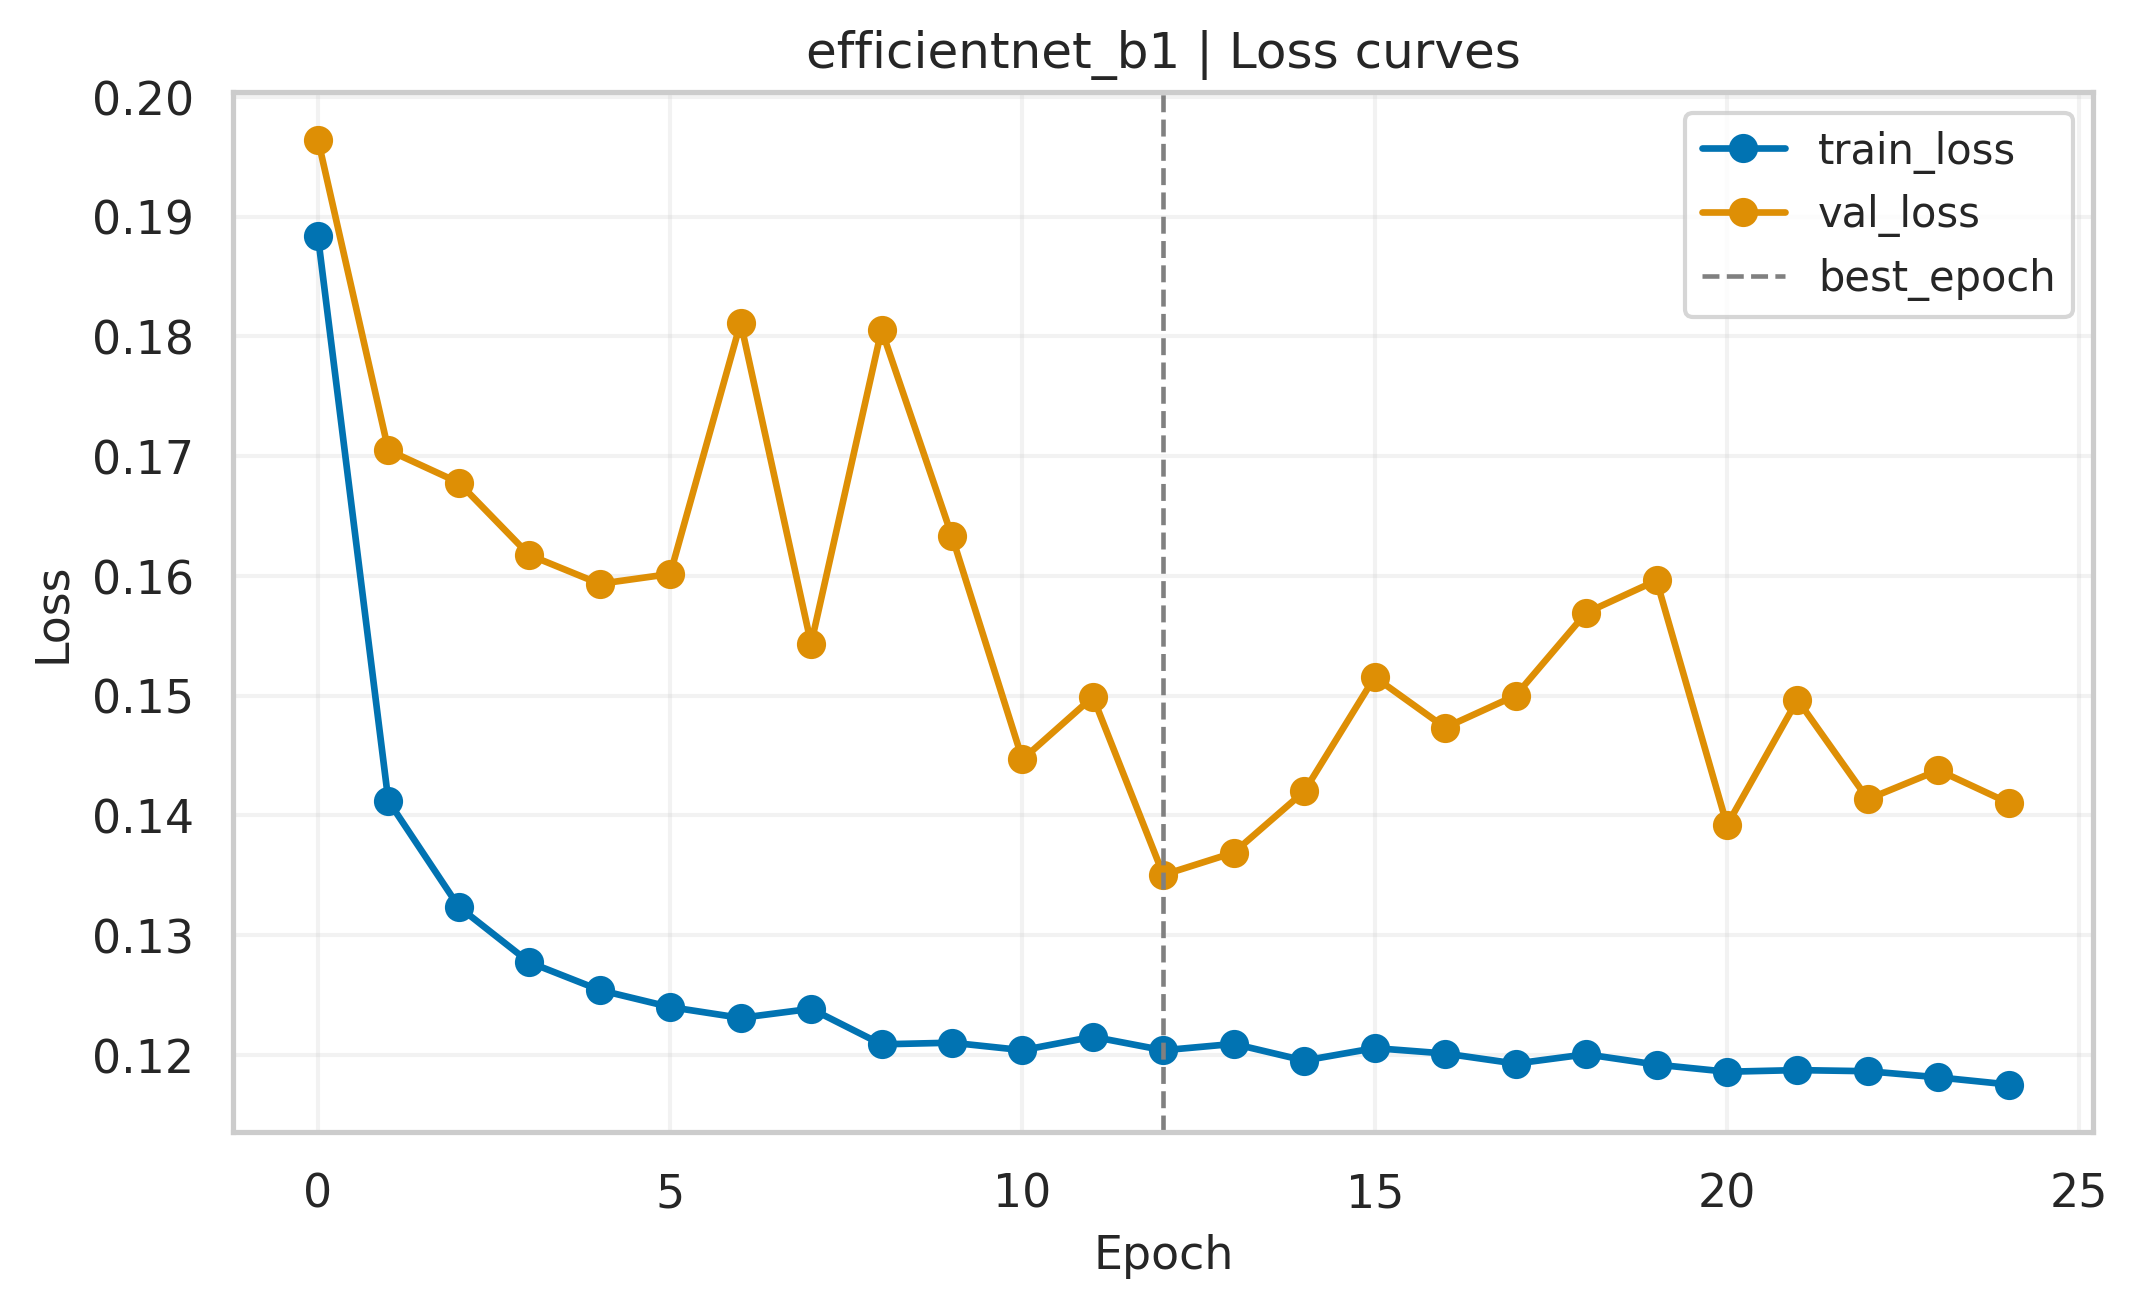

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_efficientnet_b1/plots/train_metrics.pdf


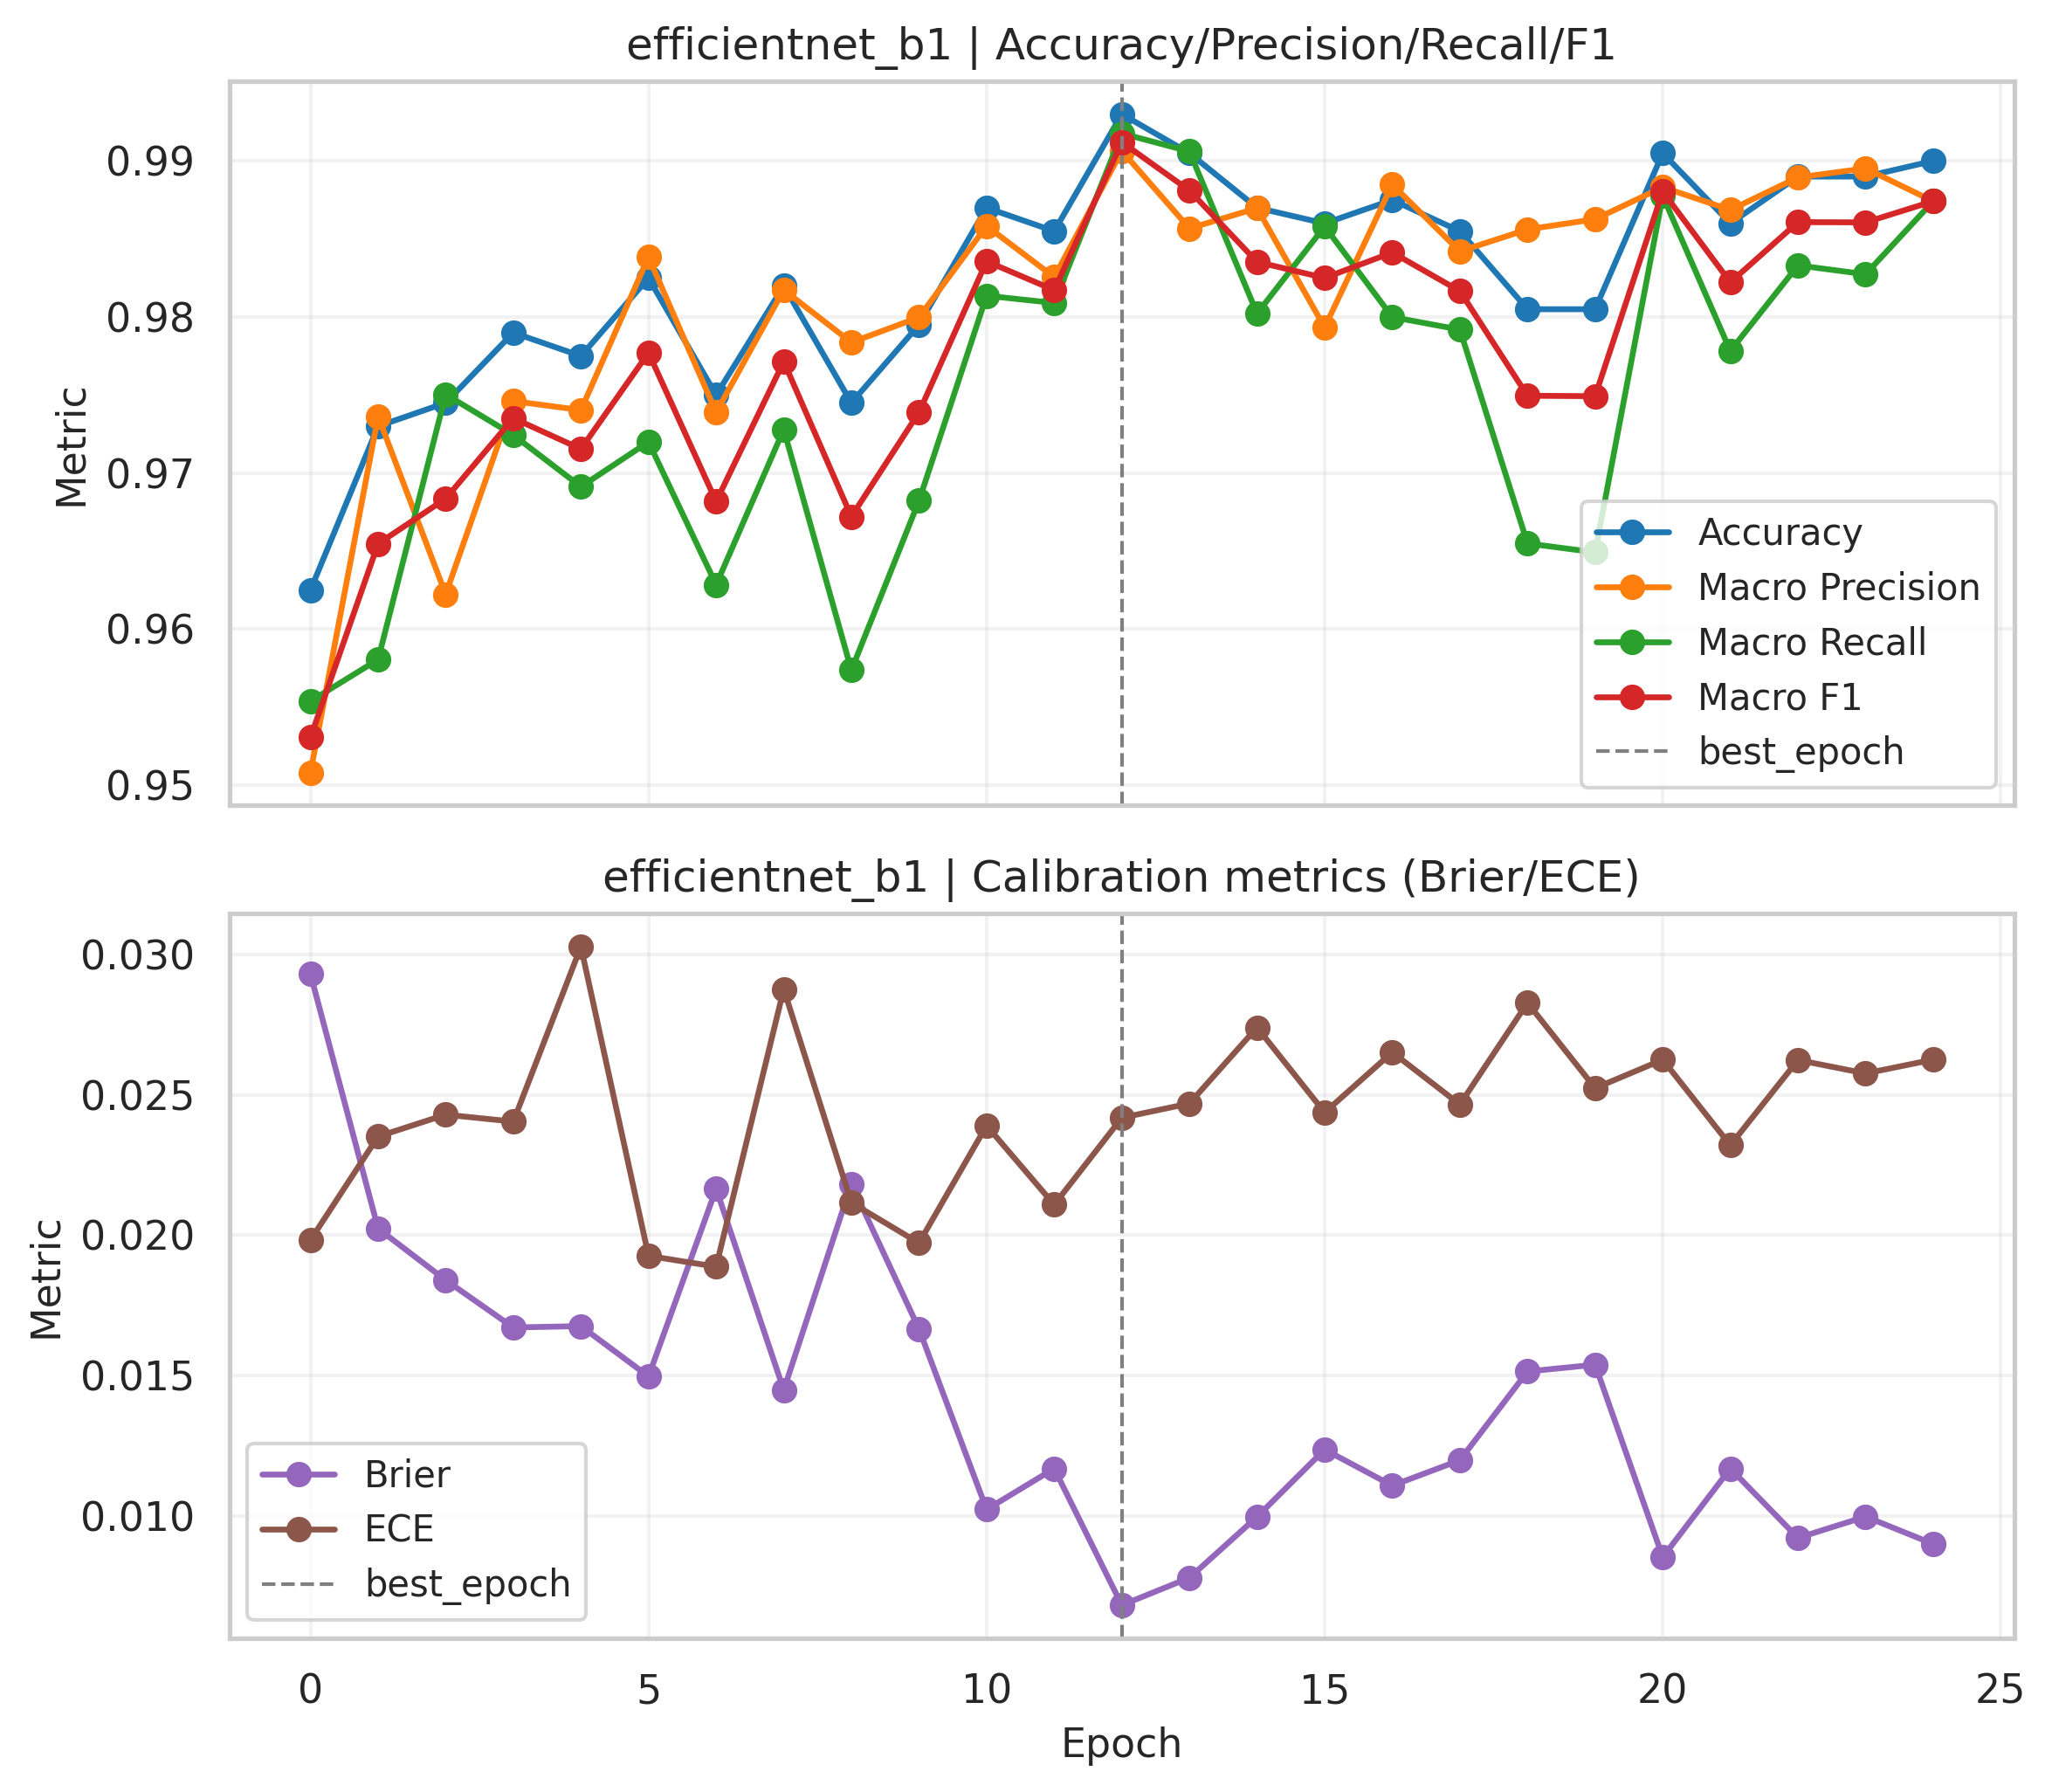

Finished training efficientnet_b1 -> training_runs/resampled_20251207-123736_efficientnet_b1
Best validation macro_f1: 0.9912


In [9]:
# efficientnet_b1 configuration + training
efficientnet_b1_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b1', 'batch_size': 48, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 240}}
efficientnet_b1_run = run_experiment("efficientnet_b1", efficientnet_b1_overrides)

Epoch 1/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-07 13:29:43,174 | INFO | Epoch 000 | train_loss=0.1771 | val_loss=0.1712 | val_f1=0.968


Epoch 2/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-07 13:30:08,766 | INFO | Epoch 001 | train_loss=0.1385 | val_loss=0.1724 | val_f1=0.969


Epoch 3/50:   0%|          | 0/527 [00:00<?, ?it/s]

...

Epoch 25/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-07 13:40:34,711 | INFO | Epoch 024 | train_loss=0.1184 | val_loss=0.1429 | val_f1=0.987


Epoch 26/50:   0%|          | 0/527 [00:00<?, ?it/s]

2025-12-07 13:41:00,647 | INFO | Epoch 025 | train_loss=0.1179 | val_loss=0.1424 | val_f1=0.987
2025-12-07 13:41:00,648 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_efficientnet_b2/plots/train_loss_curves.pdf


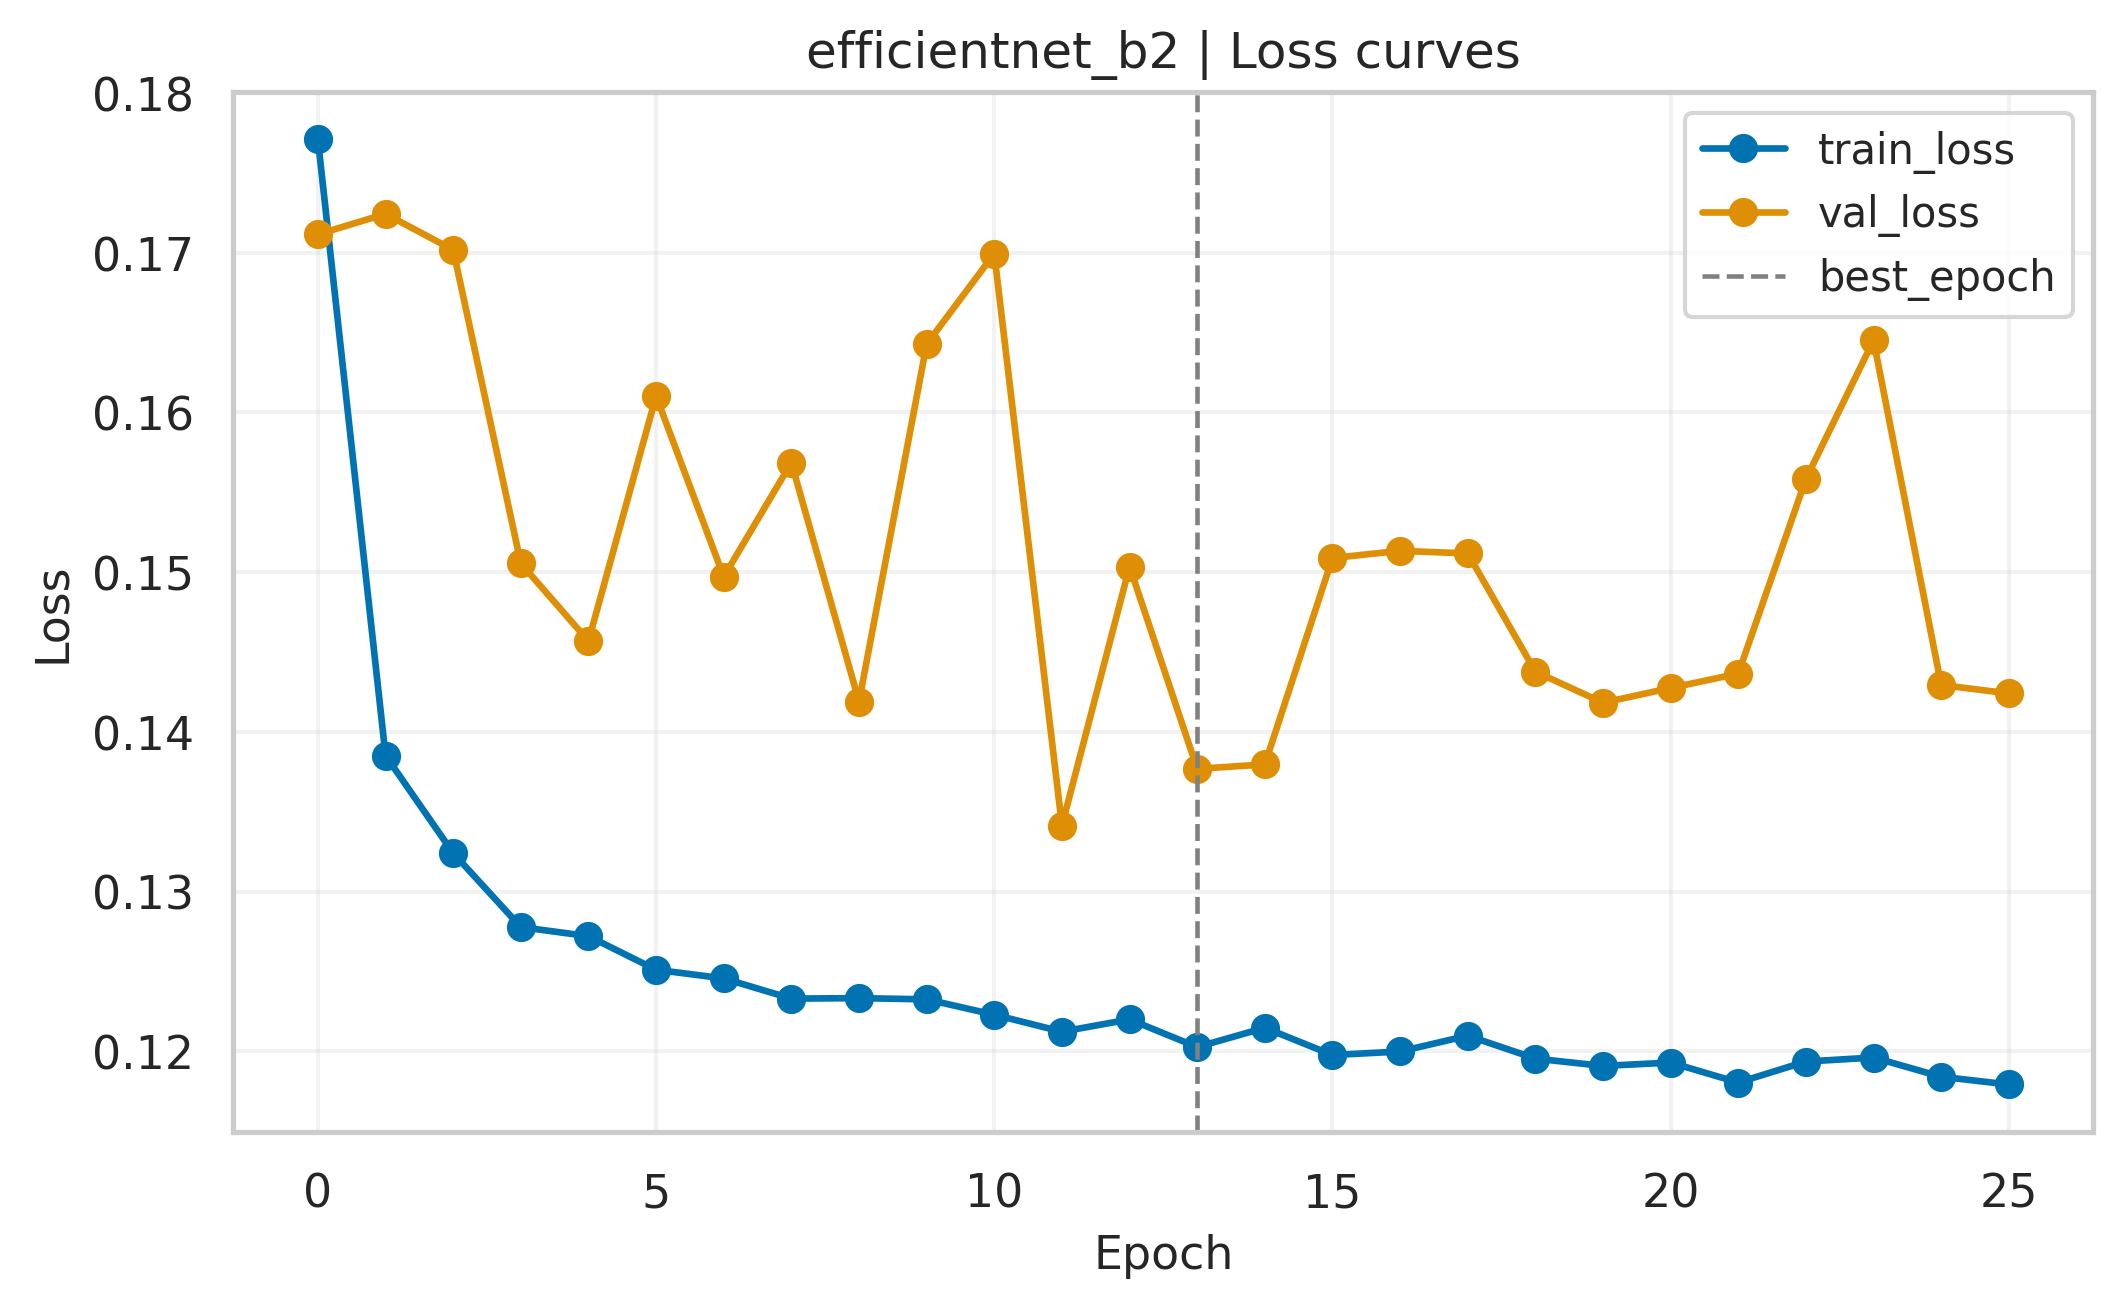

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_efficientnet_b2/plots/train_metrics.pdf


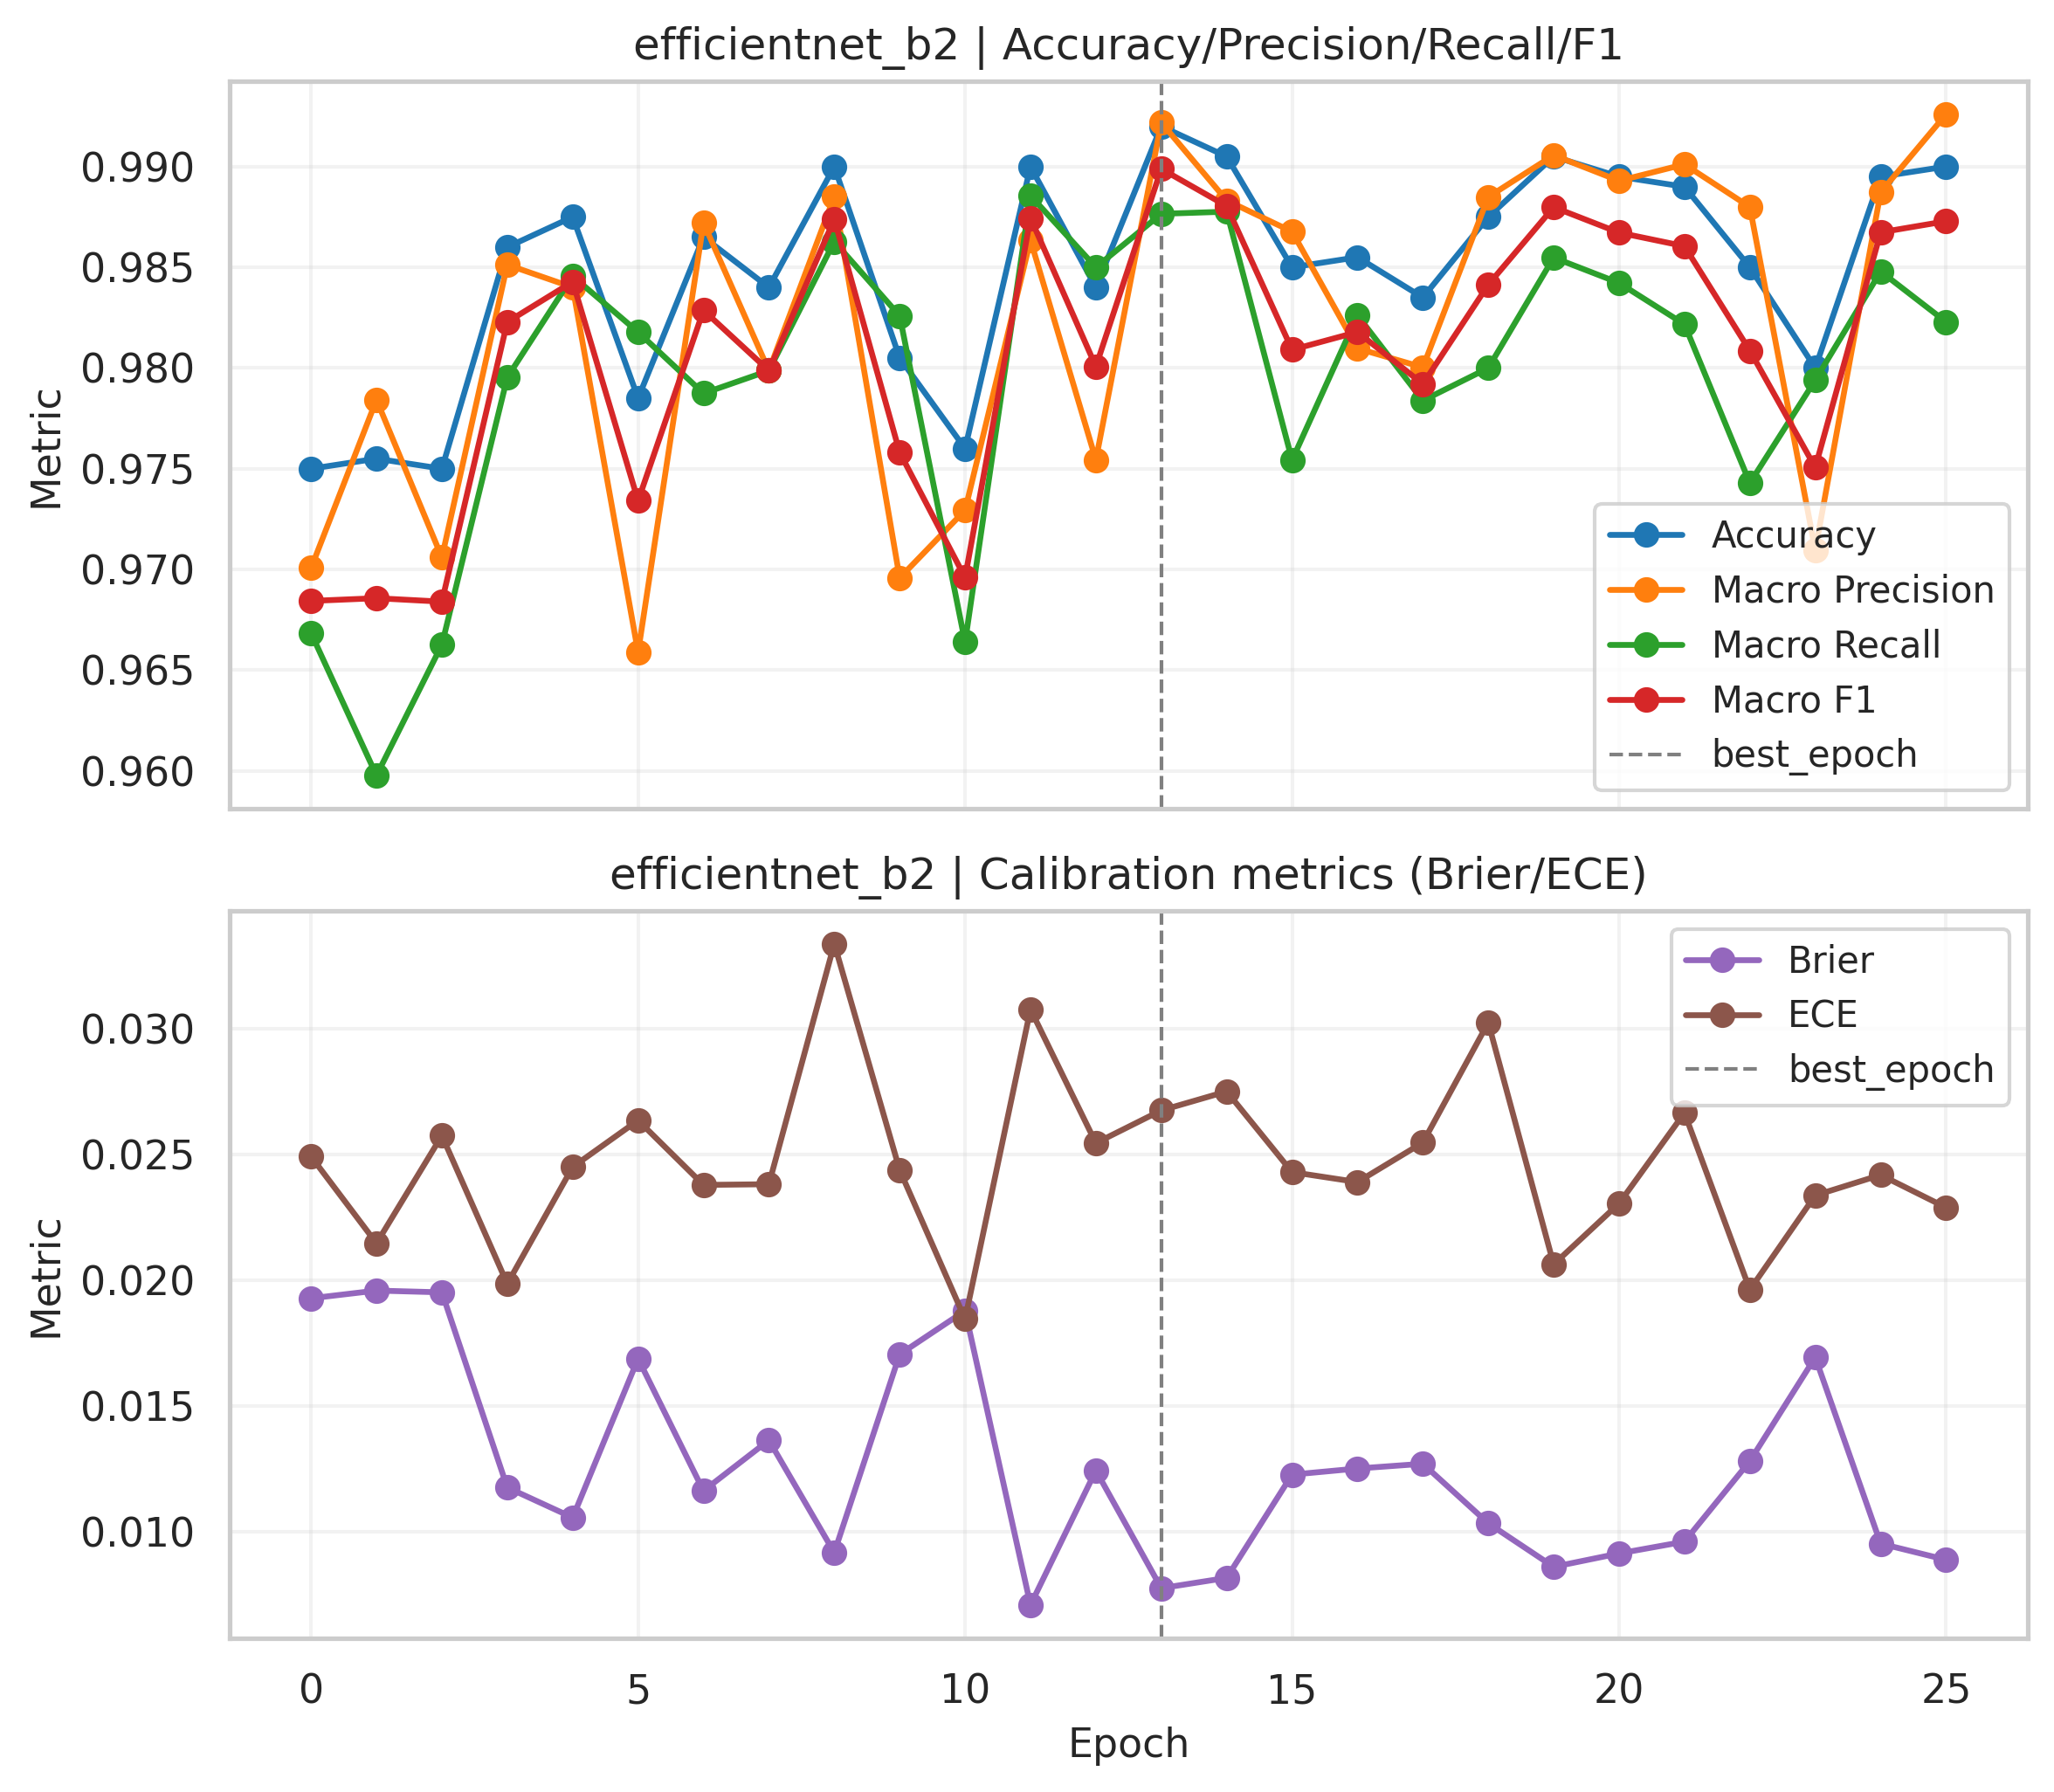

Finished training efficientnet_b2 -> training_runs/resampled_20251207-123736_efficientnet_b2
Best validation macro_f1: 0.9899


In [10]:
# efficientnet_b2 configuration + training
efficientnet_b2_overrides = {**BASE_OVERRIDES, **{'model_name': 'efficientnet_b2', 'batch_size': 36, 'lr': 0.0003, 'dropout': 0.3, 'image_size': 260}}
efficientnet_b2_run = run_experiment("efficientnet_b2", efficientnet_b2_overrides)

Epoch 1/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:41:35,373 | INFO | Epoch 000 | train_loss=0.2238 | val_loss=0.2317 | val_f1=0.930


Epoch 2/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:41:59,961 | INFO | Epoch 001 | train_loss=0.1836 | val_loss=0.2014 | val_f1=0.948


Epoch 3/50:   0%|          | 0/395 [00:00<?, ?it/s]

...

Epoch 30/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:54:07,426 | INFO | Epoch 029 | train_loss=0.1203 | val_loss=0.1585 | val_f1=0.979


Epoch 31/50:   0%|          | 0/395 [00:00<?, ?it/s]

2025-12-07 13:54:32,418 | INFO | Epoch 030 | train_loss=0.1188 | val_loss=0.1647 | val_f1=0.978
2025-12-07 13:54:32,419 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_convnext_tiny/plots/train_loss_curves.pdf


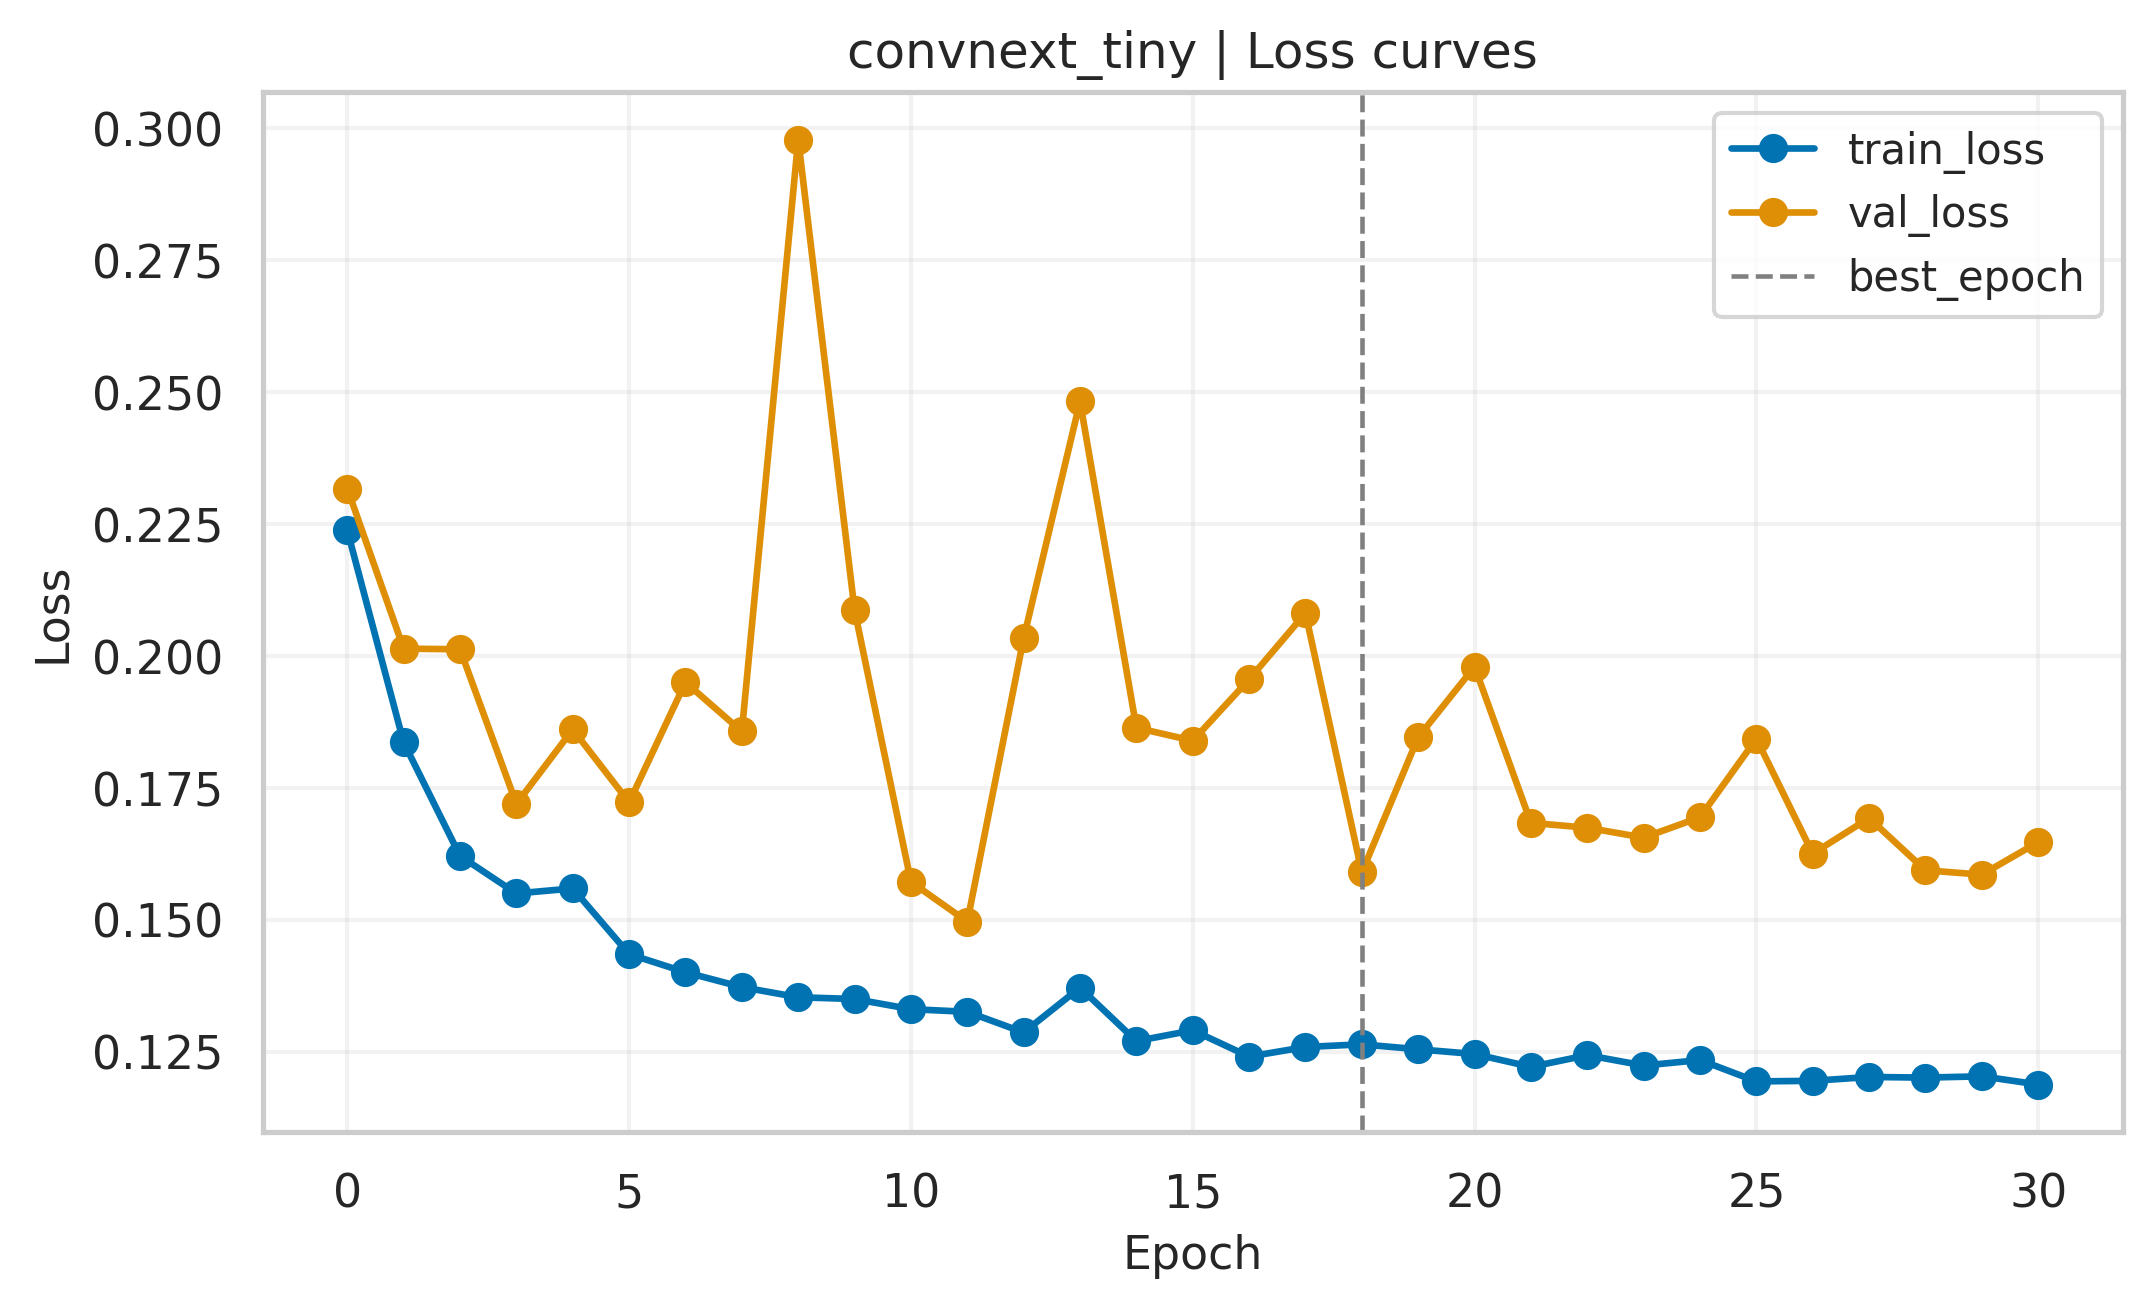

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_convnext_tiny/plots/train_metrics.pdf


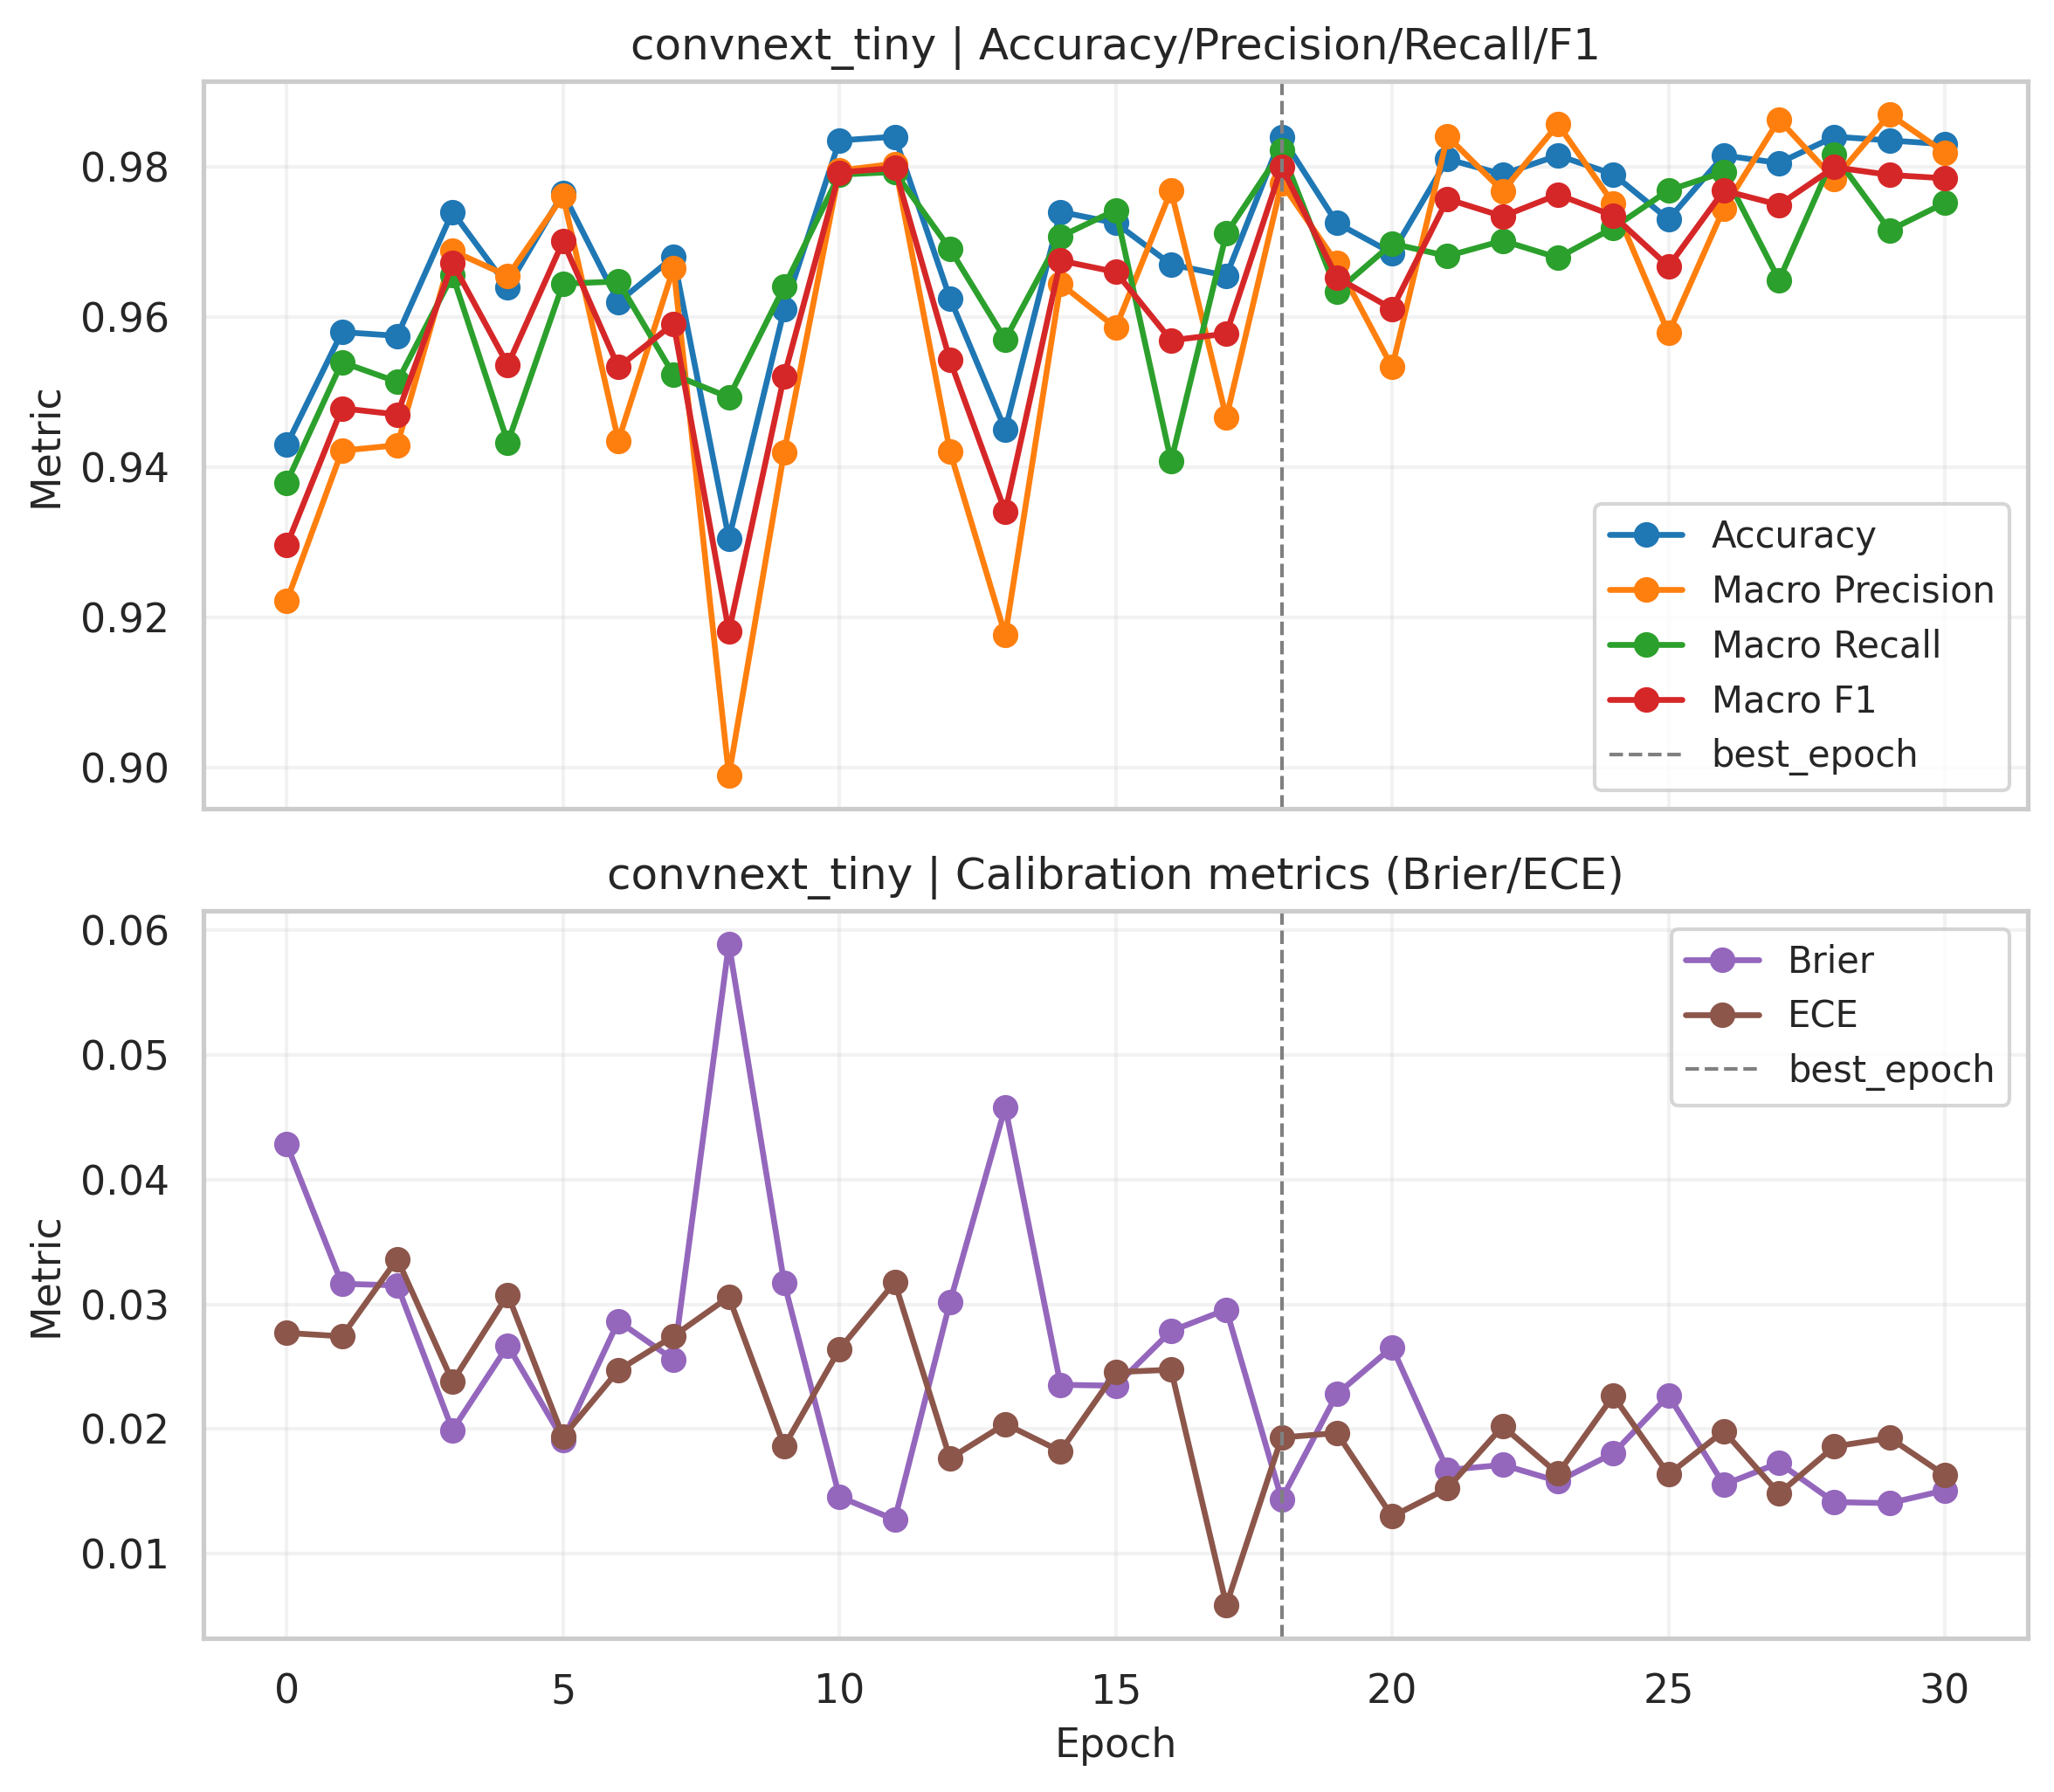

Finished training convnext_tiny -> training_runs/resampled_20251207-123736_convnext_tiny
Best validation macro_f1: 0.9800


In [11]:
# convnext_tiny configuration + training
convnext_tiny_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_tiny', 'batch_size': 48, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_tiny_run = run_experiment("convnext_tiny", convnext_tiny_overrides)

Epoch 1/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:55:25,045 | INFO | Epoch 000 | train_loss=0.2683 | val_loss=0.3319 | val_f1=0.889


Epoch 2/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 13:56:04,009 | INFO | Epoch 001 | train_loss=0.2030 | val_loss=0.2257 | val_f1=0.925


Epoch 3/50:   0%|          | 0/593 [00:00<?, ?it/s]

...

Epoch 34/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 14:18:33,480 | INFO | Epoch 033 | train_loss=0.1192 | val_loss=0.1591 | val_f1=0.981


Epoch 35/50:   0%|          | 0/593 [00:00<?, ?it/s]

2025-12-07 14:19:17,640 | INFO | Epoch 034 | train_loss=0.1177 | val_loss=0.1813 | val_f1=0.972
2025-12-07 14:19:17,641 | INFO | Early stopping.


Saved figure to training_runs/resampled_20251207-123736_convnext_small/plots/train_loss_curves.pdf


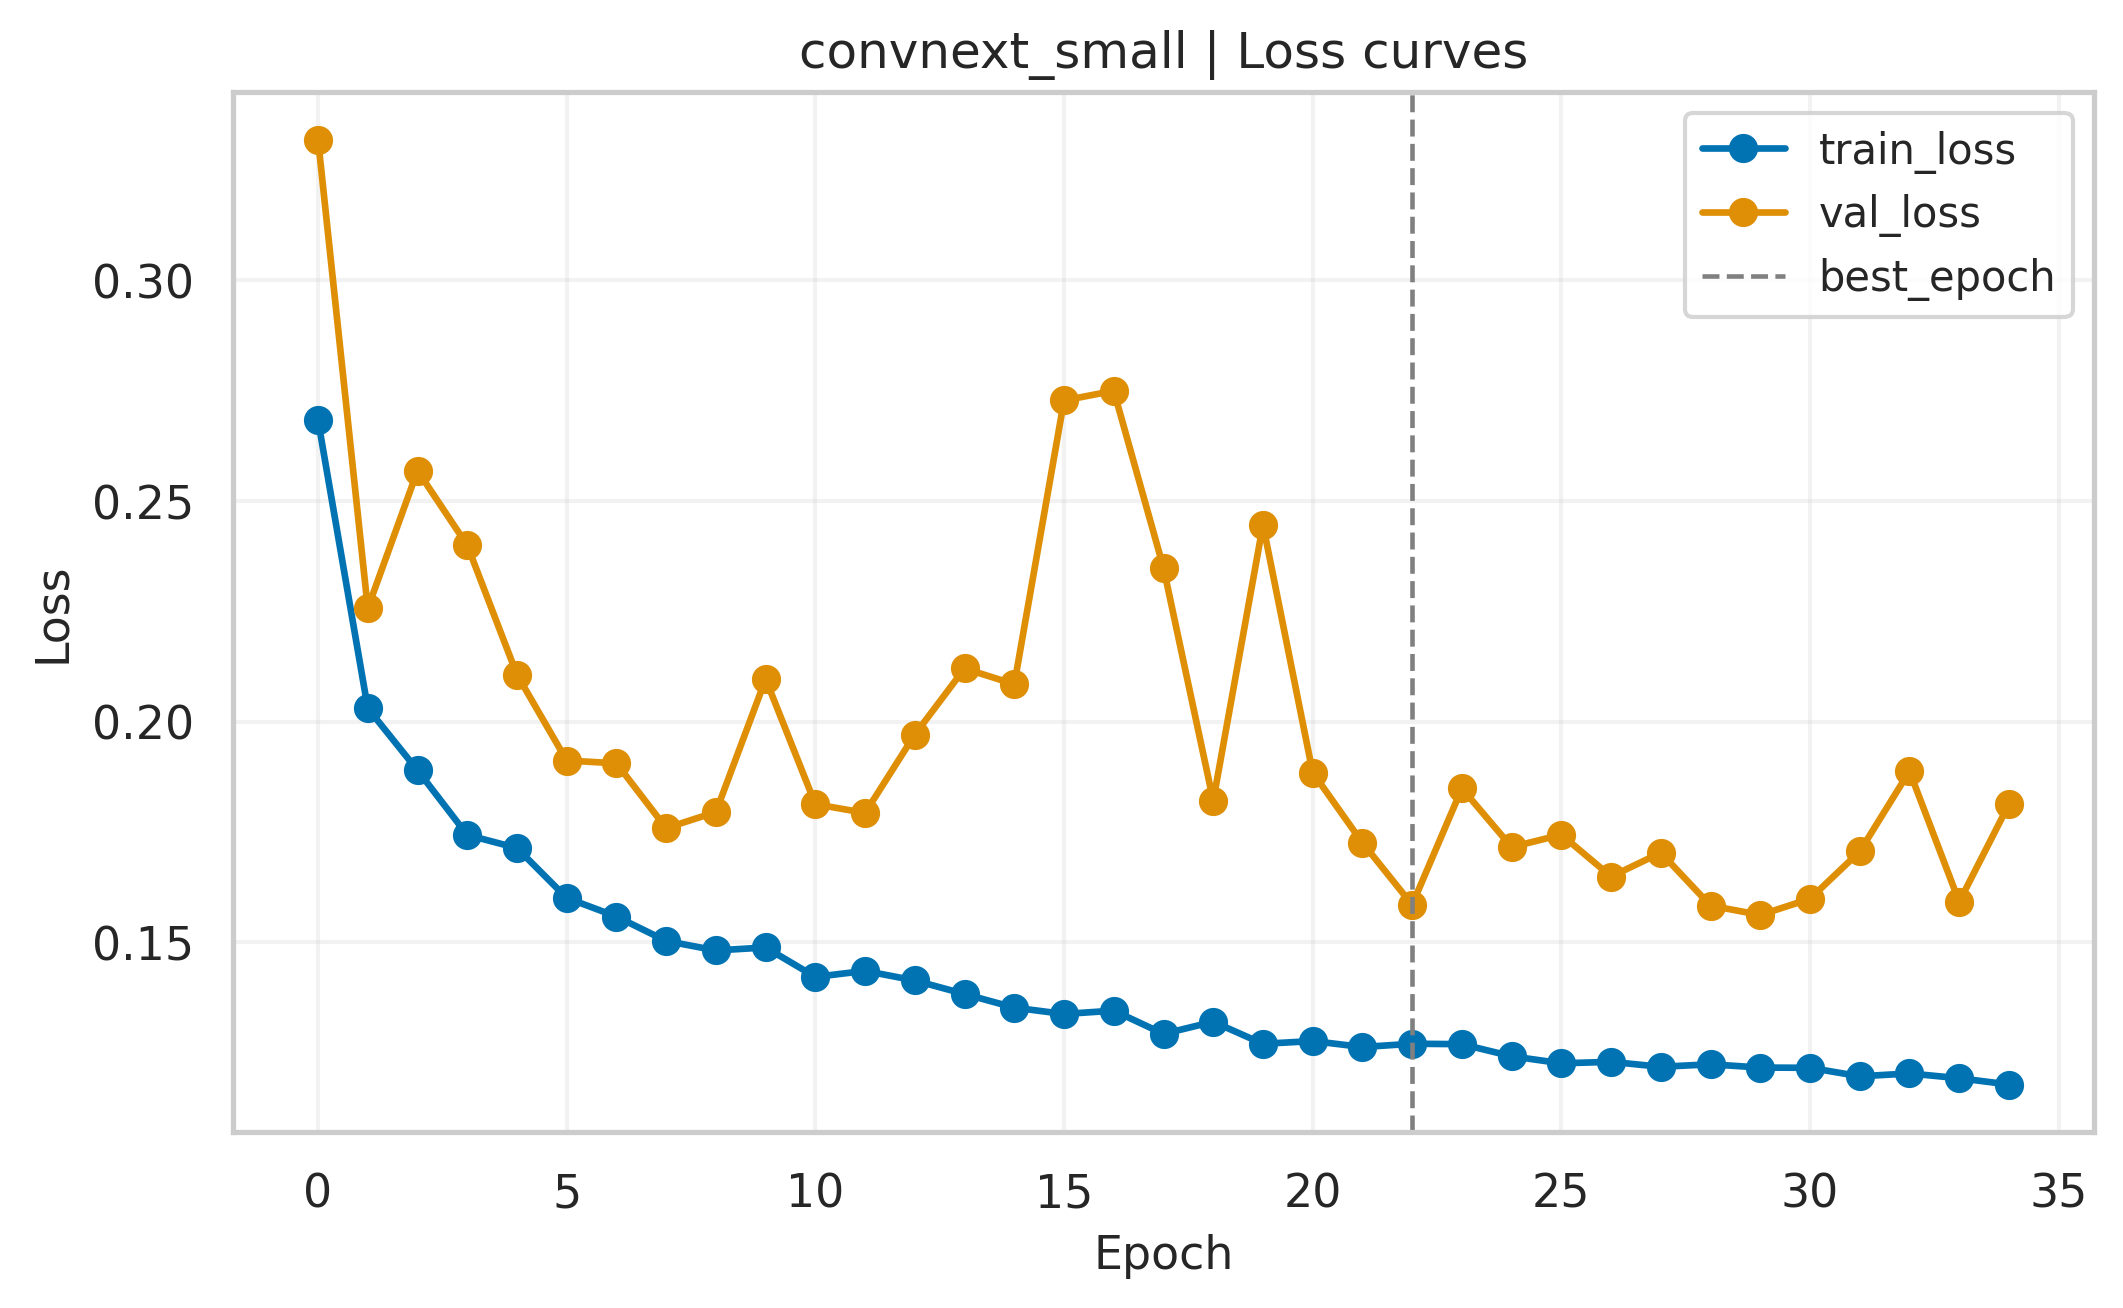

/tmp/ipykernel_36124/3877303384.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


Saved figure to training_runs/resampled_20251207-123736_convnext_small/plots/train_metrics.pdf


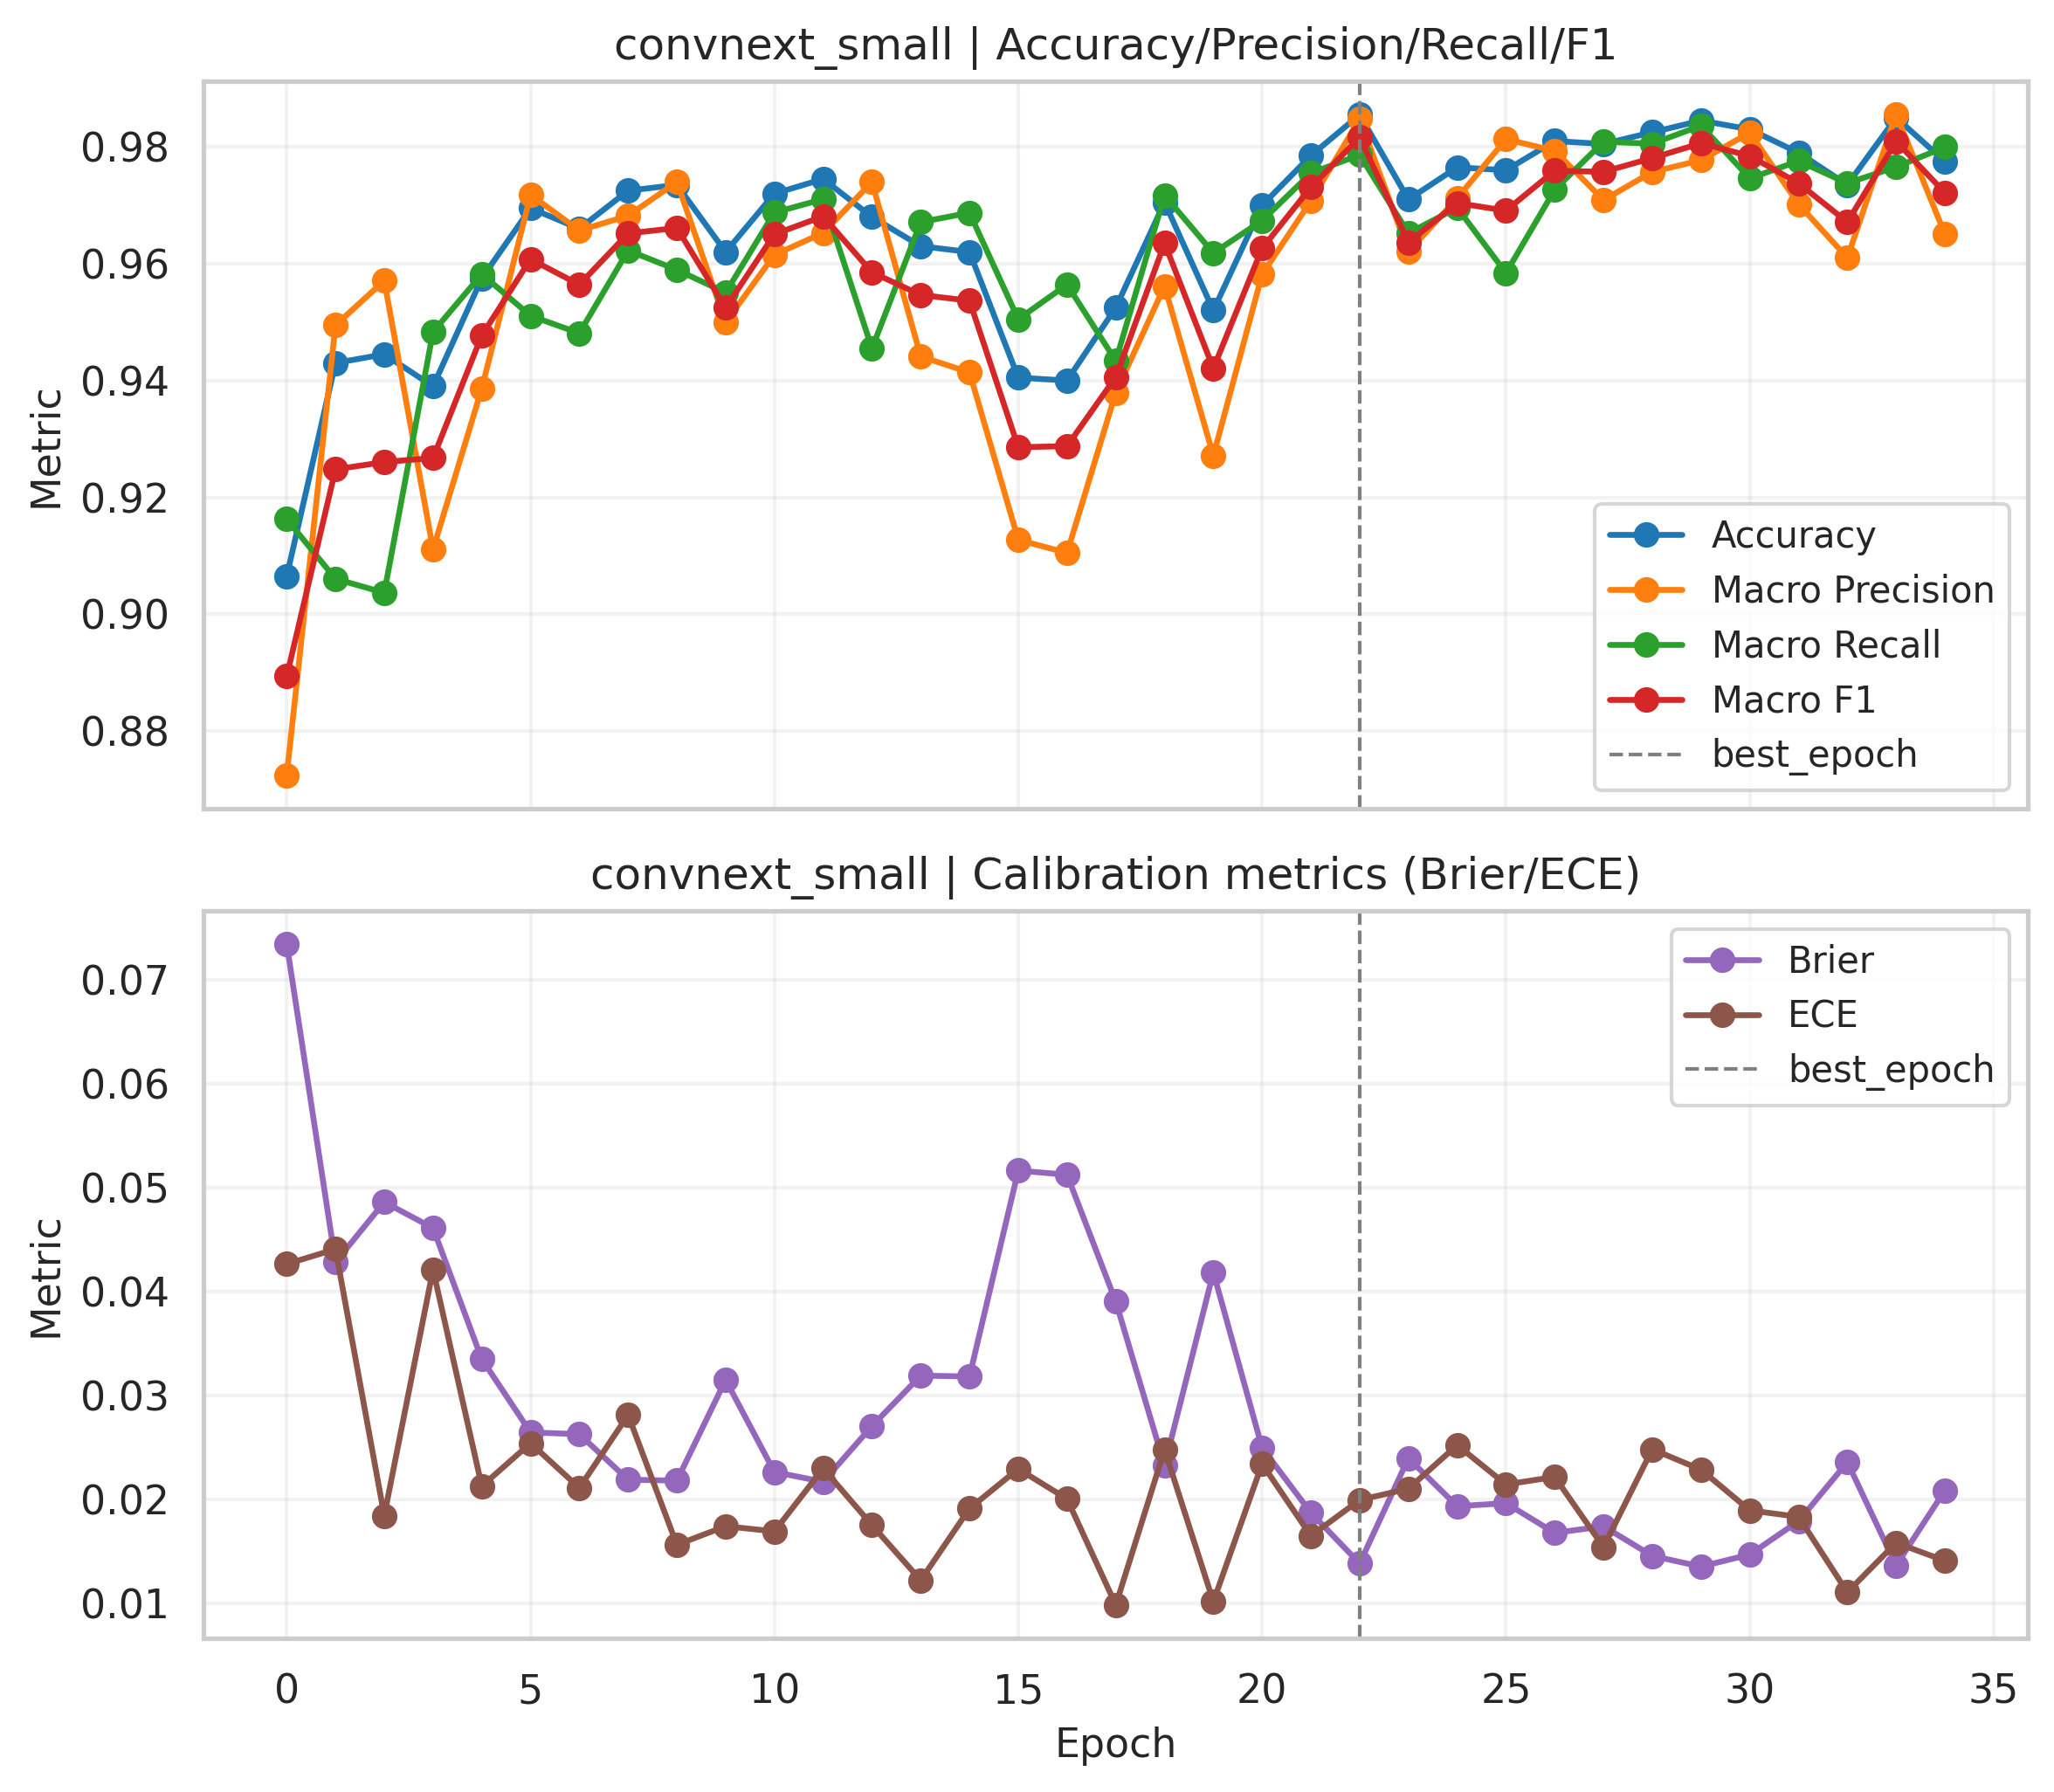

Finished training convnext_small -> training_runs/resampled_20251207-123736_convnext_small
Best validation macro_f1: 0.9816


In [12]:
# convnext_small configuration + training
convnext_small_overrides = {**BASE_OVERRIDES, **{'model_name': 'convnext_small', 'batch_size': 32, 'lr': 0.0005, 'weight_decay': 5e-05, 'image_size': 256}}
convnext_small_run = run_experiment("convnext_small", convnext_small_overrides)

In [ ]:
# custom_cnn configuration + training
custom_cnn_overrides = {**BASE_OVERRIDES, **{'model_name': 'custom_cnn', 'batch_size': 96, 'lr': 0.001, 'dropout': 0.3, 'pretrained': False, 'image_size': 256}}
custom_cnn_run = run_experiment("custom_cnn", custom_cnn_overrides)